# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 36     |  |
| :-------------|:-------------|
| Oscar Pouw          | 6409806 |
| Elisabeth Mijnders  | 6580971 |
| Lars Mulder         | 6546862 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Elisabeth', 'Oscar','Lars']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| kalibratie af | 12:00 |
| algoritmes bedacht | 14:00 |
| iteratie 0 | 15:30 | 
| iteraties  | 17:00 | 
| laatste checks / inleveren| 17:30| 
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:45-16:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto


kalibratie-opstelling groep [36]
<img src="kalibratie.jpeg" width="400">

0.034379167670892
-0.5209037891730466


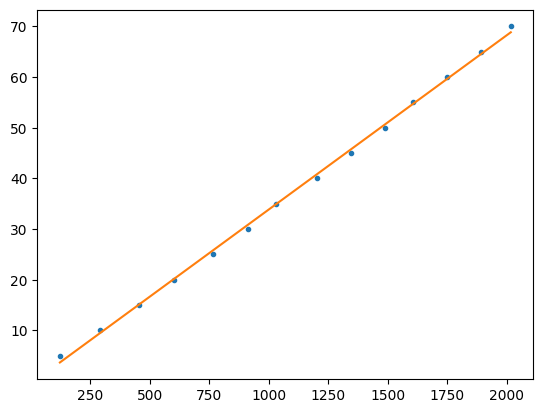

In [3]:
# verwerk hier jullie kalibratiemetingen
afstand = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7 , 0.8,  0.9,   1,    1.1, 1.2, 1.3, 1.4])*50 # cm
arduino = np.array([122, 289, 455, 600, 766, 913, 1032, 1201, 1346, 1491, 1606, 1750, 1894, 2018]) # bits

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,arduino,afstand)
a = val[0]
b = val[1]

plt.figure
plt.plot( arduino,afstand, "." )
plt.plot(arduino,fit(arduino,*val))
plt.show

print(a)
print(b)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  43.5
1   0  30   0  20  44.1
2  40   0  30   0  41.1
3  30   0  20   0  40.5


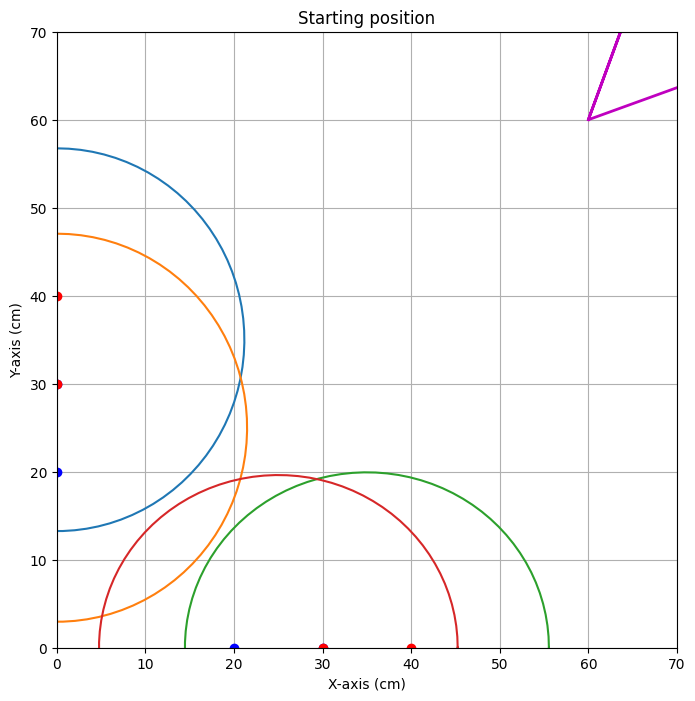


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.655


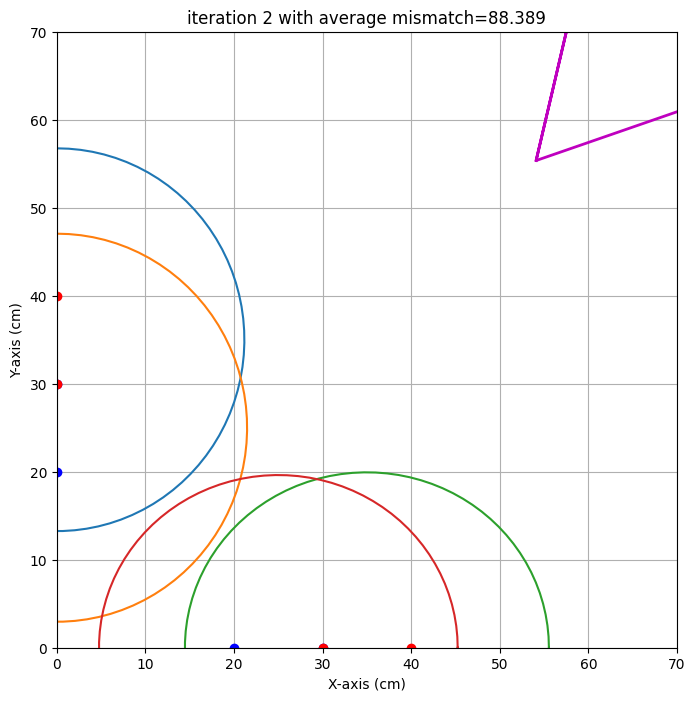

end iteration 2 with average mismatch=88.389


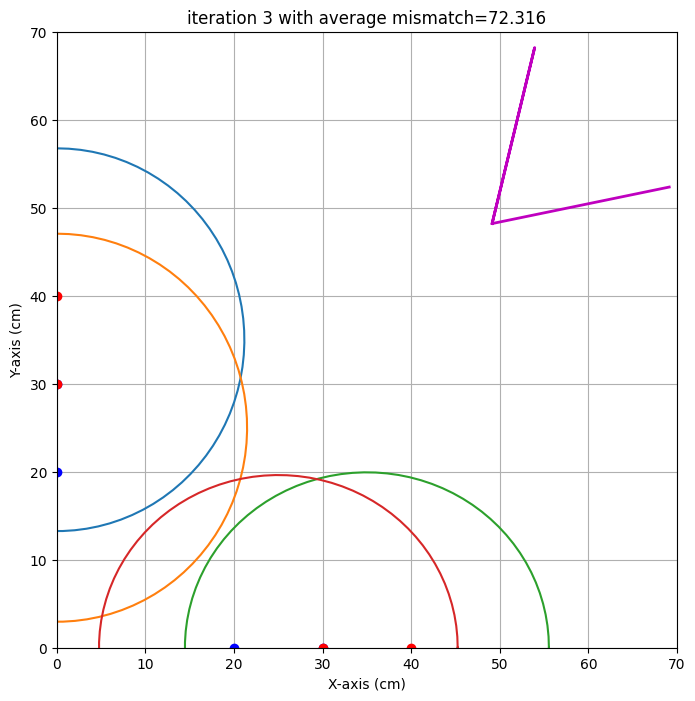

end iteration 3 with average mismatch=72.316


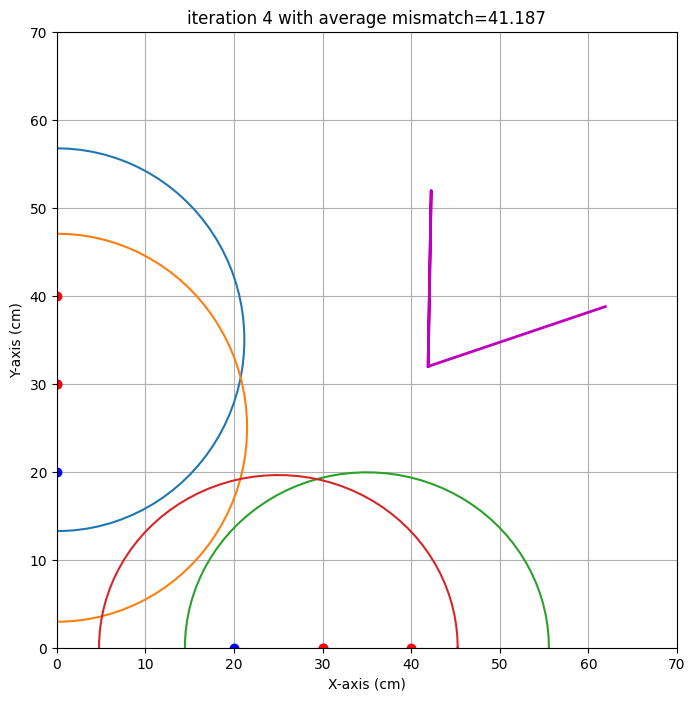

end iteration 4 with average mismatch=41.187


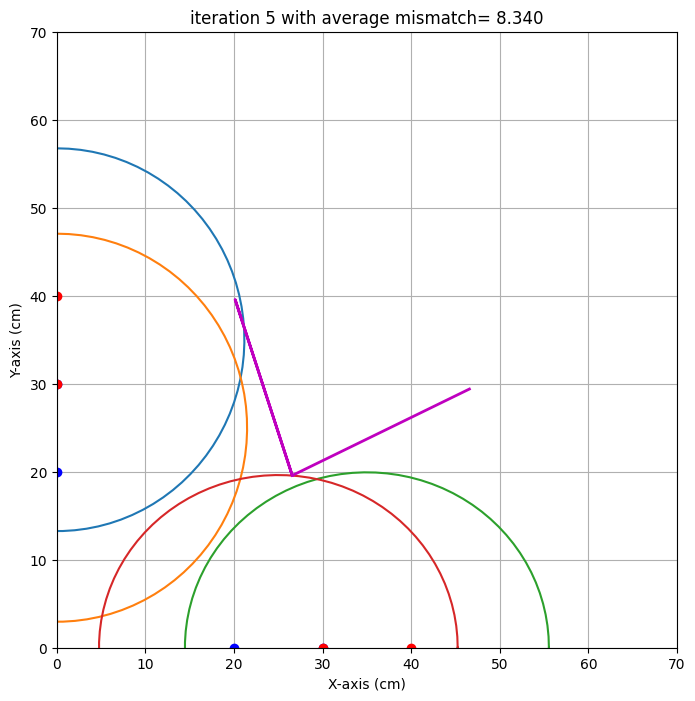

end iteration 5 with average mismatch= 8.340


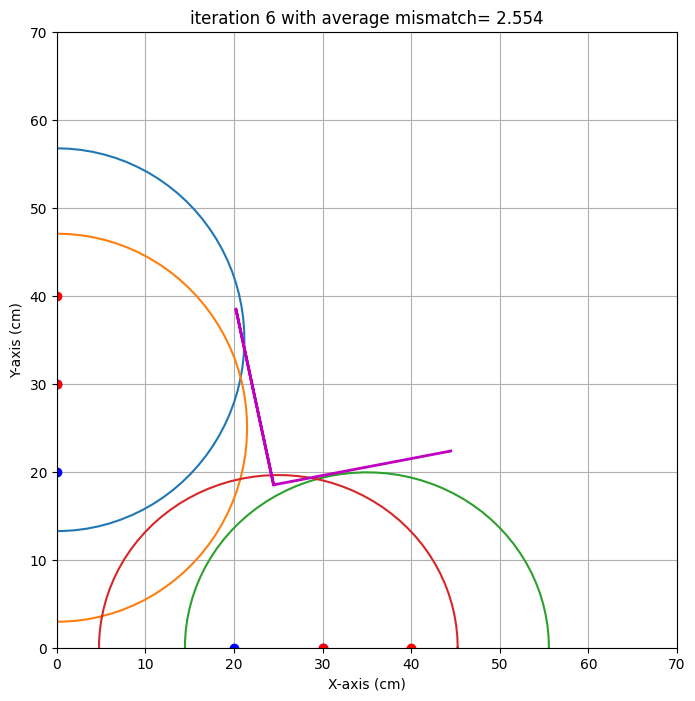

end iteration 6 with average mismatch= 2.554


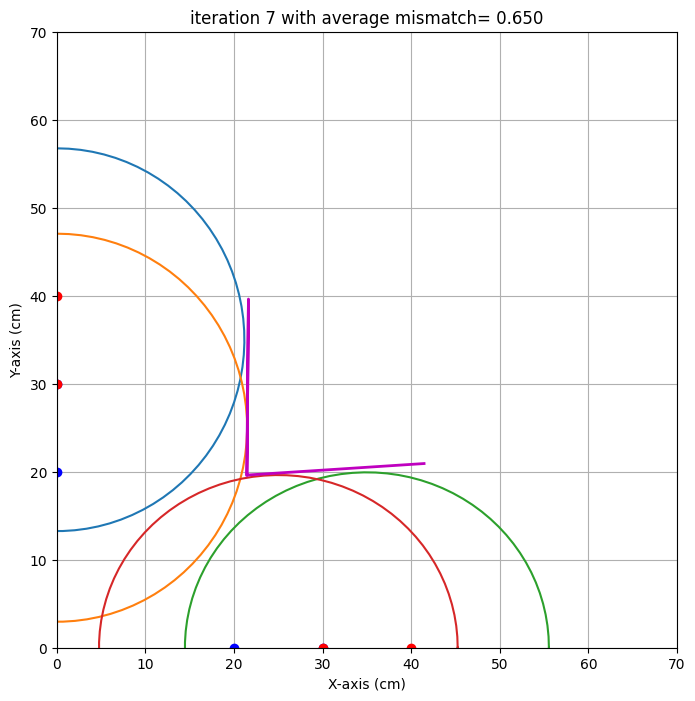

end iteration 7 with average mismatch= 0.650


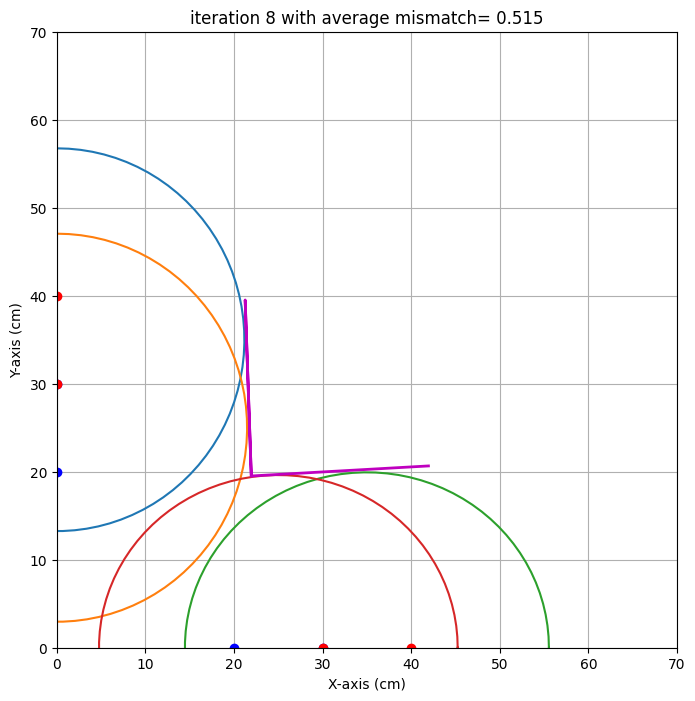

end iteration 8 with average mismatch= 0.515


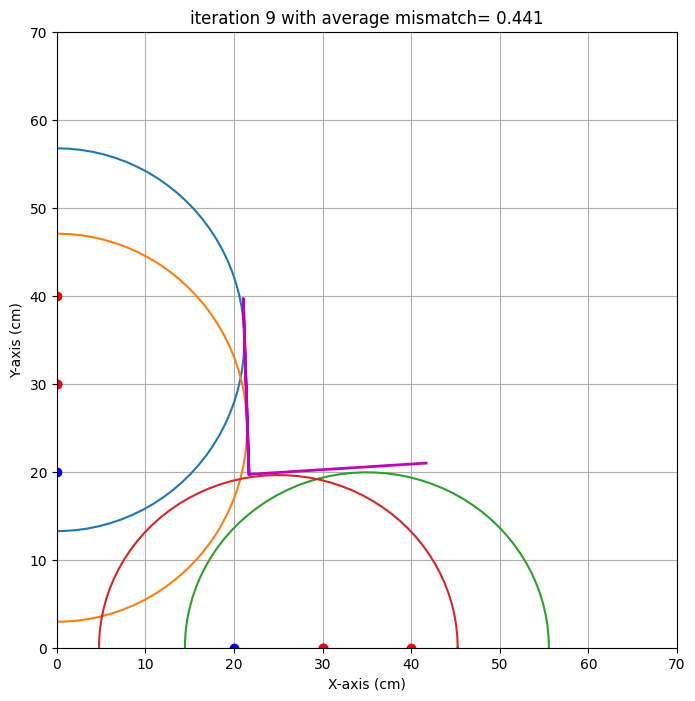

end iteration 9 with average mismatch= 0.441
end iteration 10 with average mismatch= 0.414
end iteration 11 with average mismatch= 0.414
end iteration 12 with average mismatch= 0.414
end iteration 13 with average mismatch= 0.399
end iteration 14 with average mismatch= 0.390


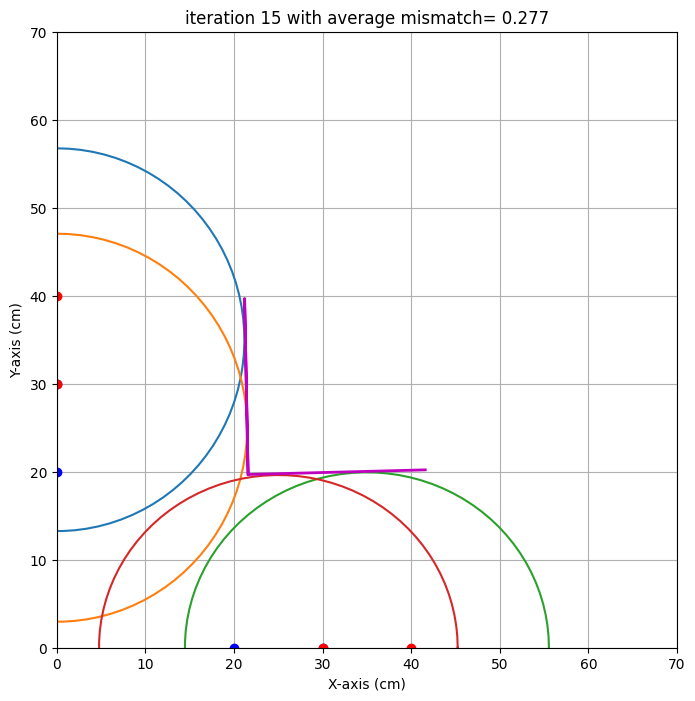

end iteration 15 with average mismatch= 0.277
end iteration 16 with average mismatch= 0.265
end iteration 17 with average mismatch= 0.263
end iteration 18 with average mismatch= 0.262
end iteration 19 with average mismatch= 0.261
end iteration 20 with average mismatch= 0.261
end iteration 21 with average mismatch= 0.261
end iteration 22 with average mismatch= 0.261
end iteration 23 with average mismatch= 0.261


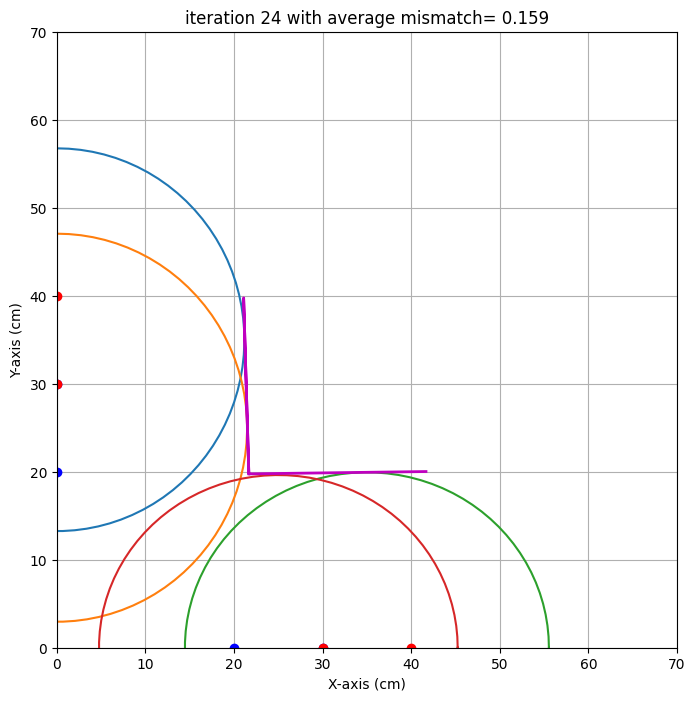

end iteration 24 with average mismatch= 0.159
end iteration 25 with average mismatch= 0.153
end iteration 26 with average mismatch= 0.152
end iteration 27 with average mismatch= 0.152
end iteration 28 with average mismatch= 0.152
end iteration 29 with average mismatch= 0.152
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.152
###############################################################################
end of iteration  30
Best alpha=   0.76 with uncertainty=   1.08
Best beta =  -1.69 with uncertainty=   0.02
Best x0   =  21.66 with uncertainty=   0.16
Best y0   =  19.75 with uncertainty=   0.14
###############################################################################


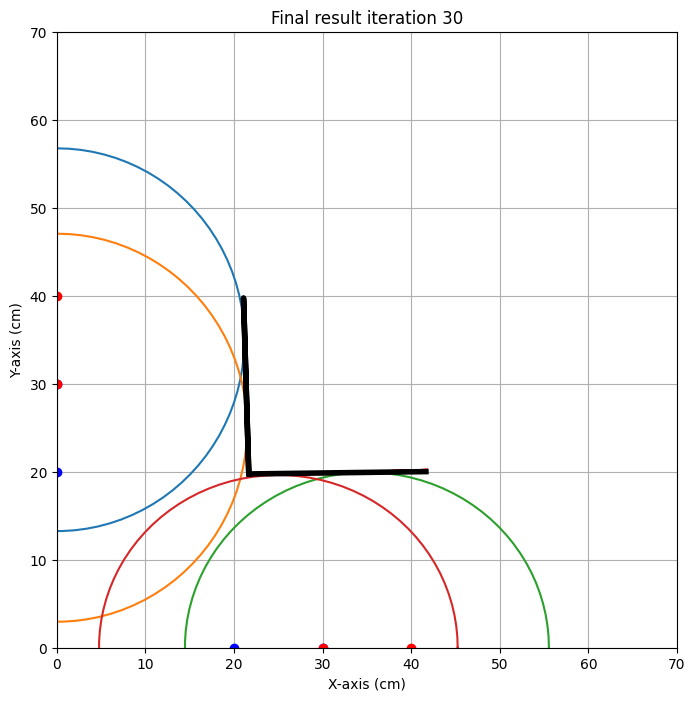

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,43.5],
    [0,30,0,20,44.1],
    #[0,10,0,20,ongeldig],
    [40,0,30,0,41.1],
    [30,0,20,0,40.5],
    #[10,0,20,0,ongeldig],
    #[10,0,0,10,ongeldig]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.7 cm met een standaardafwijking van 0.2 cm 
y0: 19.7 cm met een standaardafwijking van 0.1 cm 
alpha: 0.8 graden met een standaardafwijking van 1.1 graad 
beta: -1.7 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Lars Mulder]
<img src="Algoritme_Lars.jpeg" width="400">

#### algoritme [Elisabeth Mijnders]
<img src="Algoritme_Elisabeth.jpeg" width="400">

#### algoritme [Oscar Pouw]
<img src="Algoritme_Oscar.jpg" width="400">


## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 26.5,  
           'y0': 34.5,
           'alpha' : 13 ,
           'beta' : 13 ,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Lars' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,68],
    [0,60,0,50,59.2],
    [0,50,0,40,54.1],
    #[0,40,0,30,],
    #[0,30,0,20,],
    #[0,20,0,10,],
    #[0,10,0,20,],
    #[70,0,60,0,],
    [60,0,50,0,79],
    [50,0,40,0,75.8],
    [40,0,30,0,71.6],
    #[30,0,20,0,],
    #[20,0,10,0,0],
    #[10,0,20,0,0],
    
    ]),
       'Elisabeth' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[25,0,35,0,ongeldig],
    [35,0,45,0,72.6],
    [40,0,50,0,74.9],
   # [0,25,0,35,ongeldig],
    [0,35,0,45,55.5],
    [0,40,0,50,54.5],

    ]),
       'Oscar' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,74.1],
    [50,0,60,0,79.1],
    [60,0,70,0,86.5],
    [30,0,40,0,71],
    #[20,0,30,0,ongeldig],
    [0,40,0,50,53],
    [0,50,0,60,60],
    [0,60,0,70,67],
    #[0,30,0,40,ongeldig],
    
    ]),
      }

## Opdracht 7: Evaluatie.

Elisabeth
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  72.6
1  40   0  50   0  74.9
2   0  35   0  45  55.5
3   0  40   0  50  54.5


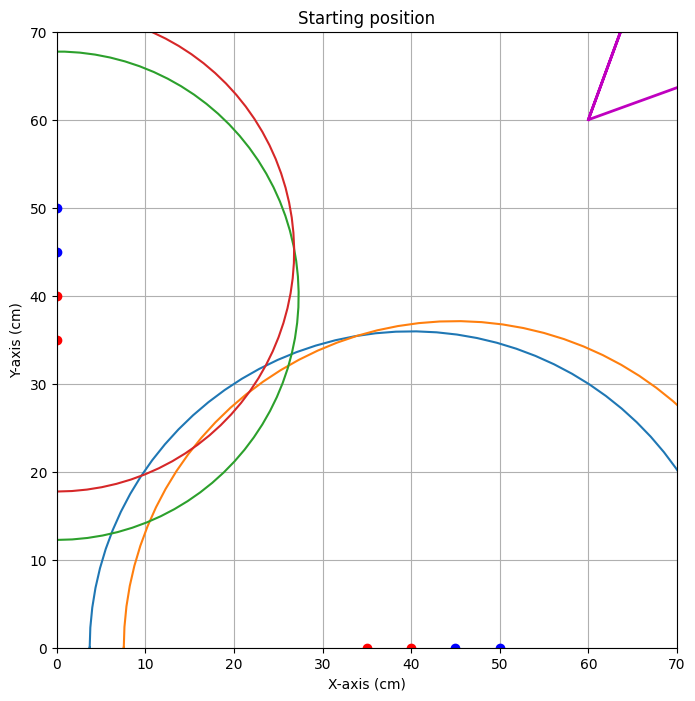


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=67.723


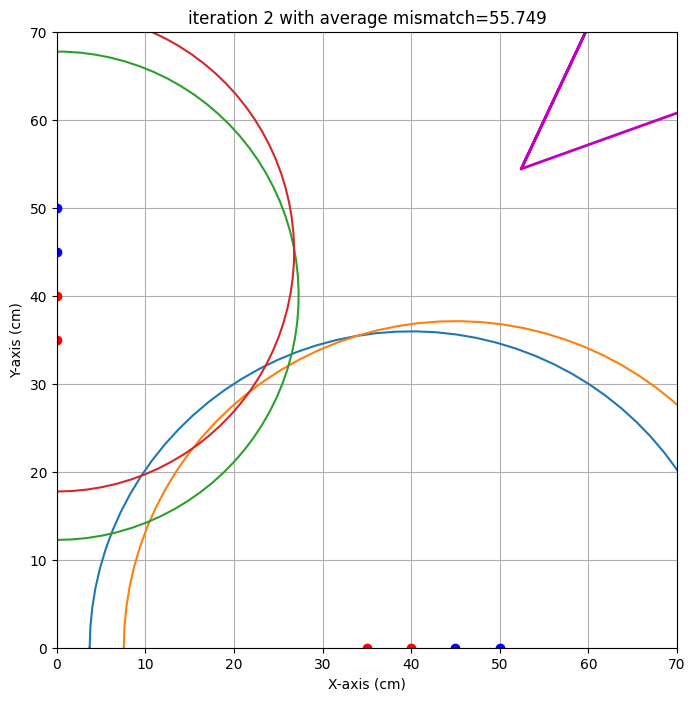

end iteration 2 with average mismatch=55.749


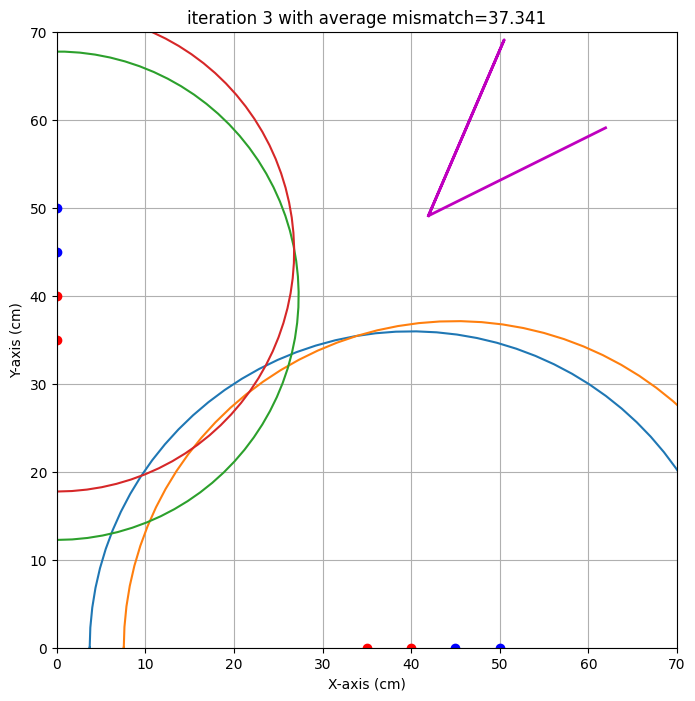

end iteration 3 with average mismatch=37.341


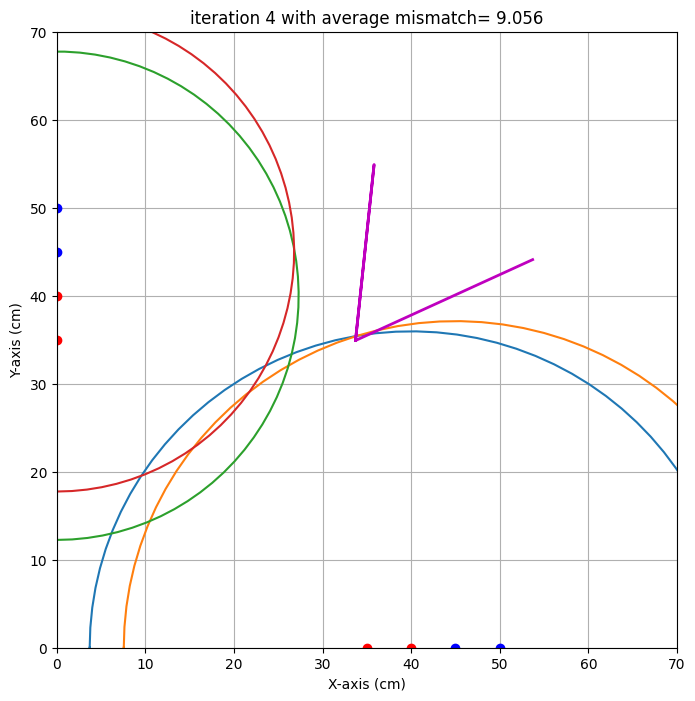

end iteration 4 with average mismatch= 9.056


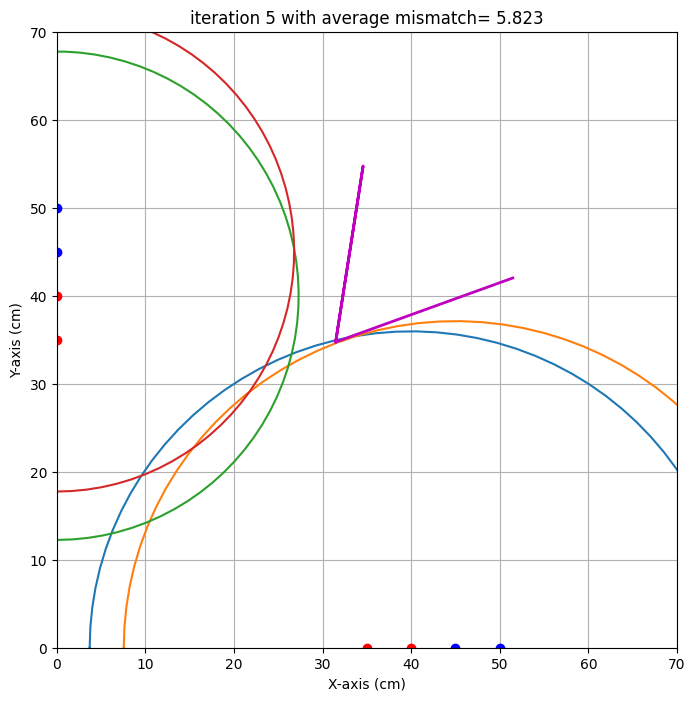

end iteration 5 with average mismatch= 5.823


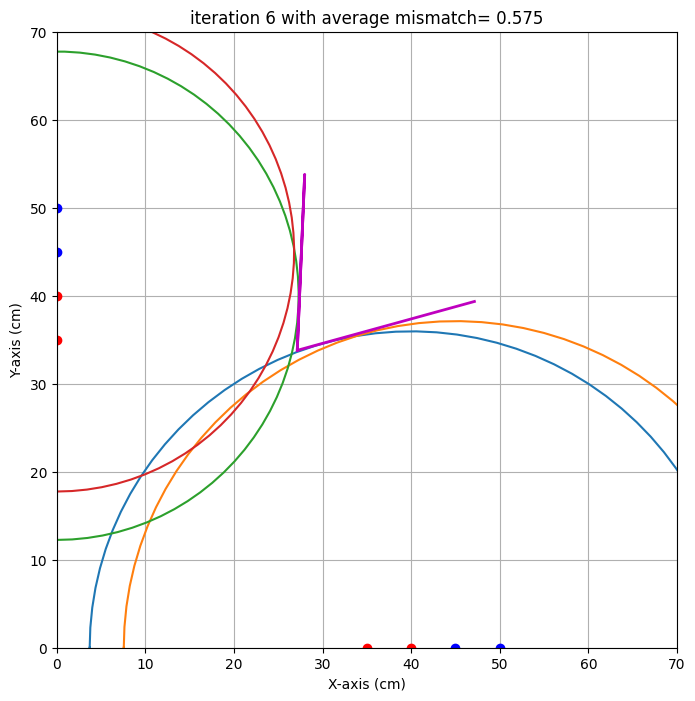

end iteration 6 with average mismatch= 0.575
end iteration 7 with average mismatch= 0.543
end iteration 8 with average mismatch= 0.541
end iteration 9 with average mismatch= 0.541
end iteration 10 with average mismatch= 0.541


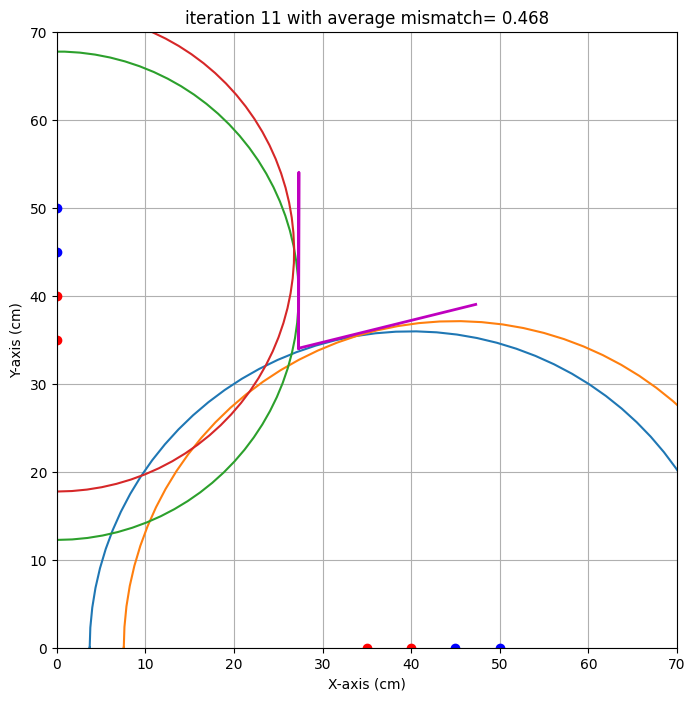

end iteration 11 with average mismatch= 0.468


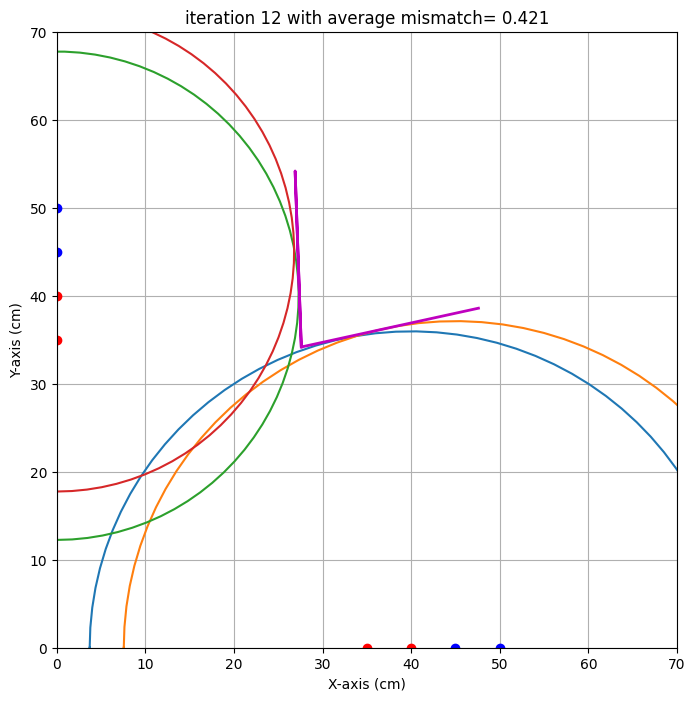

end iteration 12 with average mismatch= 0.421
end iteration 13 with average mismatch= 0.409


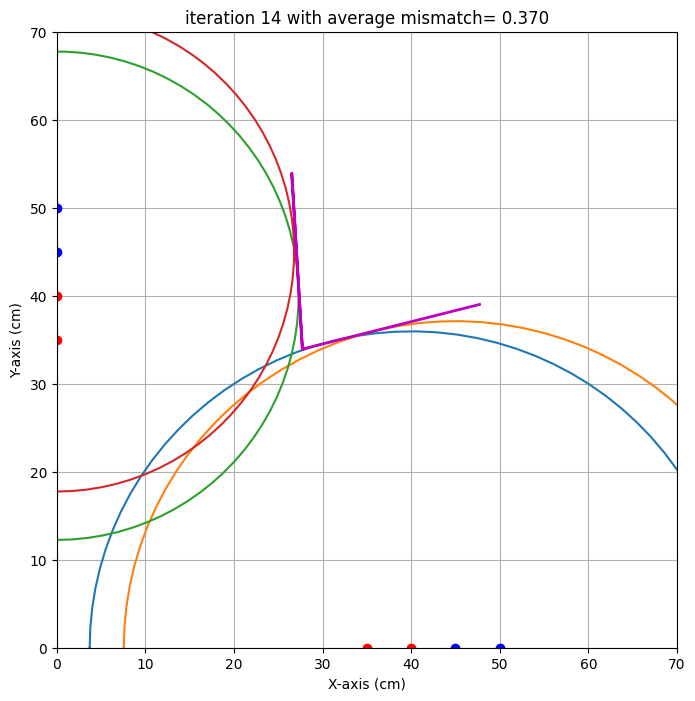

end iteration 14 with average mismatch= 0.370
end iteration 15 with average mismatch= 0.366
end iteration 16 with average mismatch= 0.366


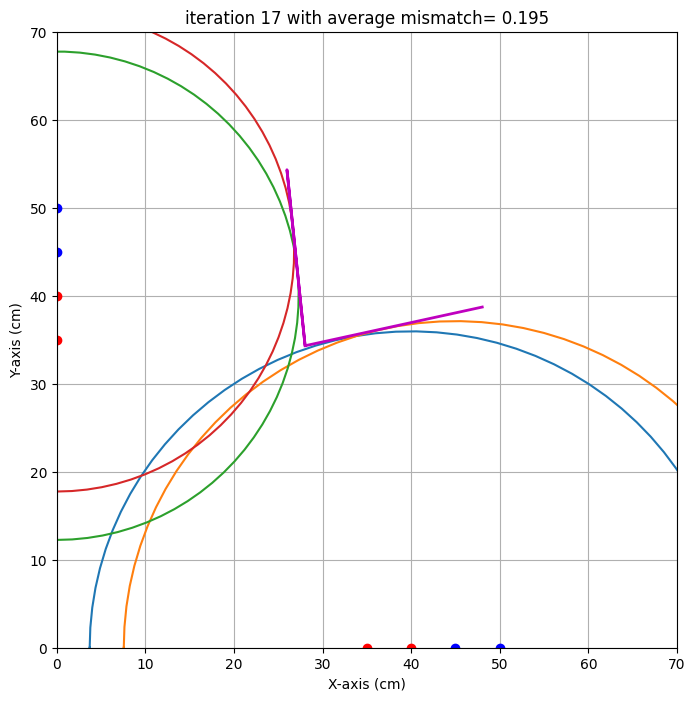

end iteration 17 with average mismatch= 0.195
end iteration 18 with average mismatch= 0.195
end iteration 19 with average mismatch= 0.195
end iteration 20 with average mismatch= 0.195
end iteration 21 with average mismatch= 0.195
end iteration 22 with average mismatch= 0.195
end iteration 23 with average mismatch= 0.195
end iteration 24 with average mismatch= 0.195
end iteration 25 with average mismatch= 0.195
end iteration 26 with average mismatch= 0.185


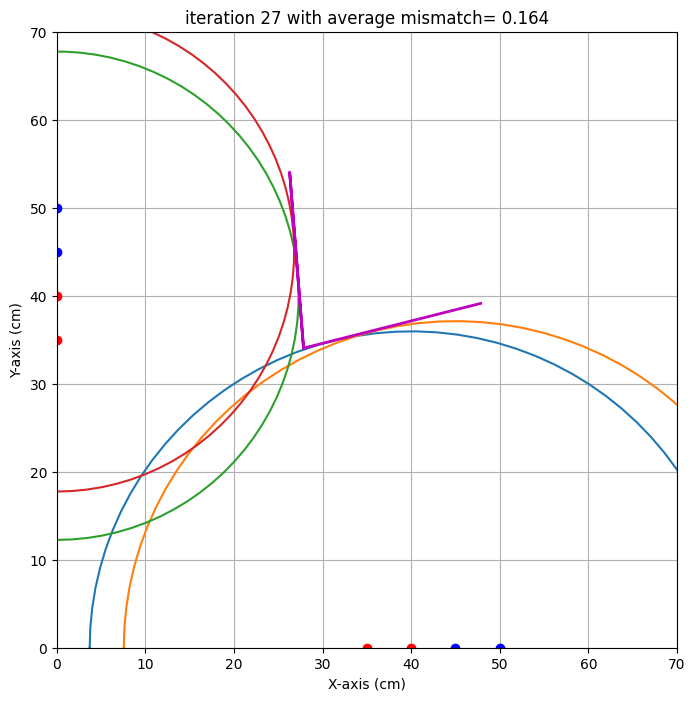

end iteration 27 with average mismatch= 0.164
end iteration 28 with average mismatch= 0.163
end iteration 29 with average mismatch= 0.163
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.163
###############################################################################
end of iteration  30
Best alpha=  14.26 with uncertainty=   2.26
Best beta =  -4.48 with uncertainty=   3.59
Best x0   =  27.84 with uncertainty=   0.81
Best y0   =  34.04 with uncertainty=   0.60
###############################################################################


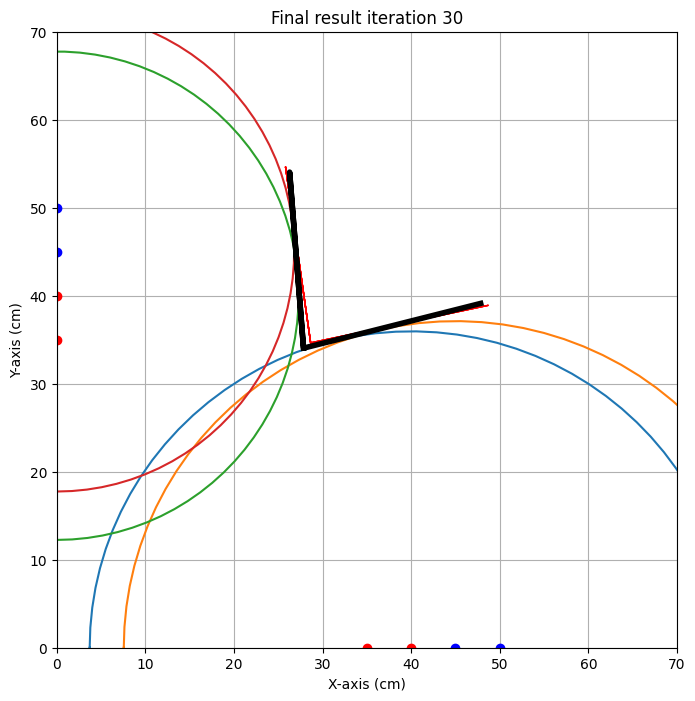

{'alpha': np.float64(14.256389420320176), 'alpha_eps': np.float64(2.2563315521661558), 'beta': np.float64(-4.482844166436841), 'beta_eps': np.float64(3.5919184384902003), 'x0': np.float64(27.842928524579012), 'x0_eps': np.float64(0.8058836584085931), 'y0': np.float64(34.043191304141864), 'y0_eps': np.float64(0.6021378284327241)}
Oscar
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  74.1
1  50   0  60   0  79.1
2  60   0  70   0  86.5
3  30   0  40   0  71.0
4   0  40   0  50  53.0
5   0  50   0  60  60.0
6   0  60   0  70  67.0


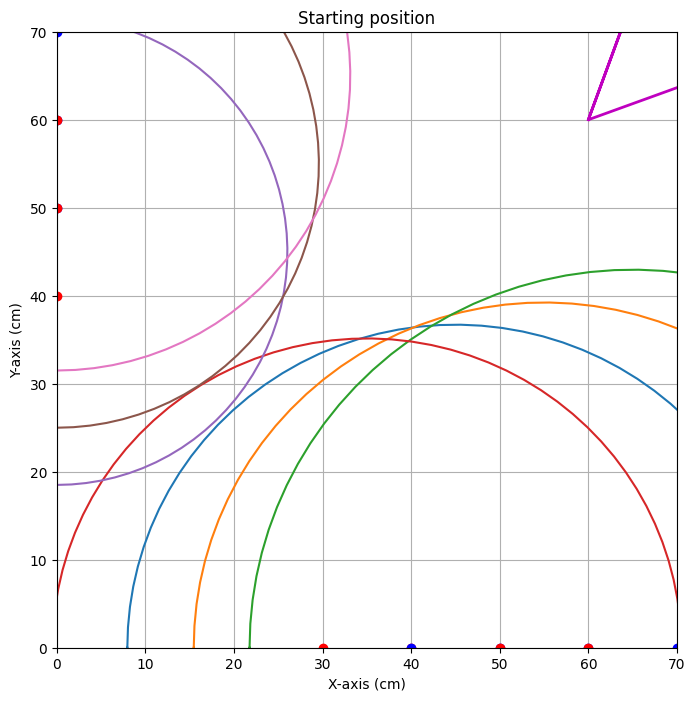


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.175


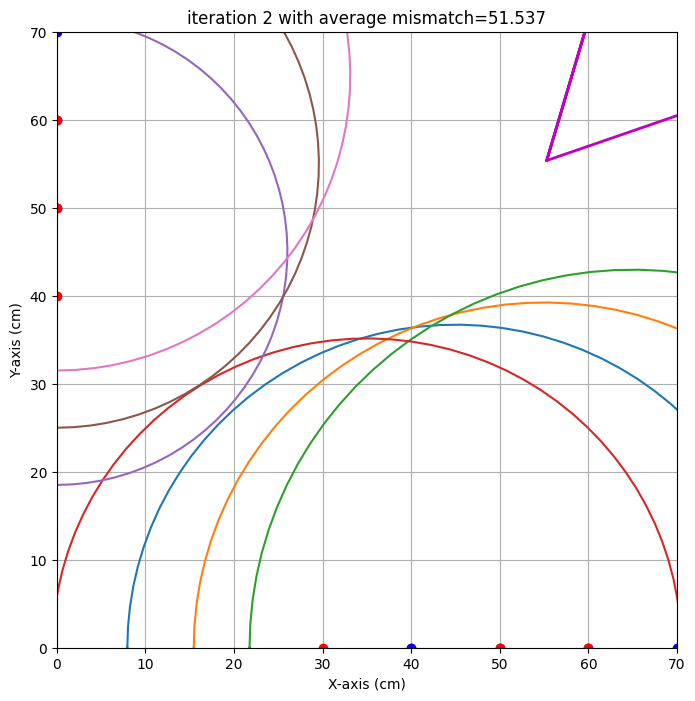

end iteration 2 with average mismatch=51.537


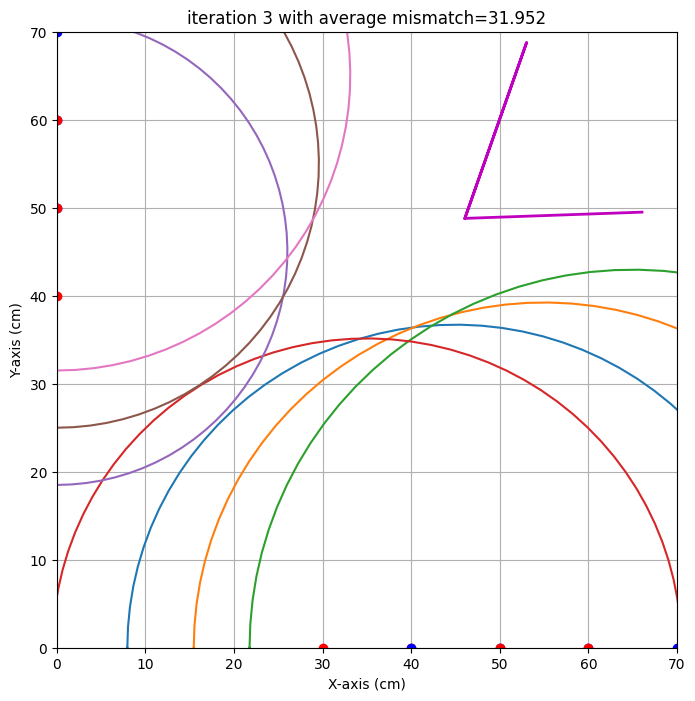

end iteration 3 with average mismatch=31.952


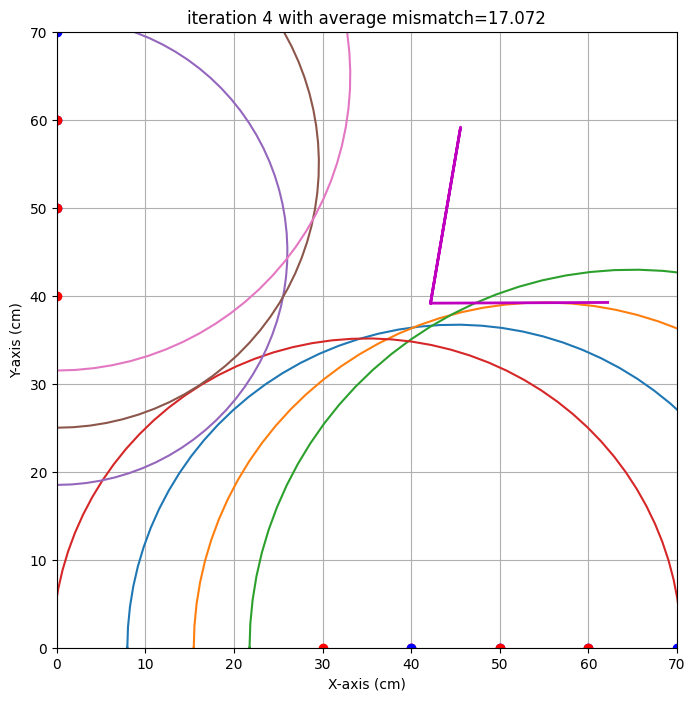

end iteration 4 with average mismatch=17.072


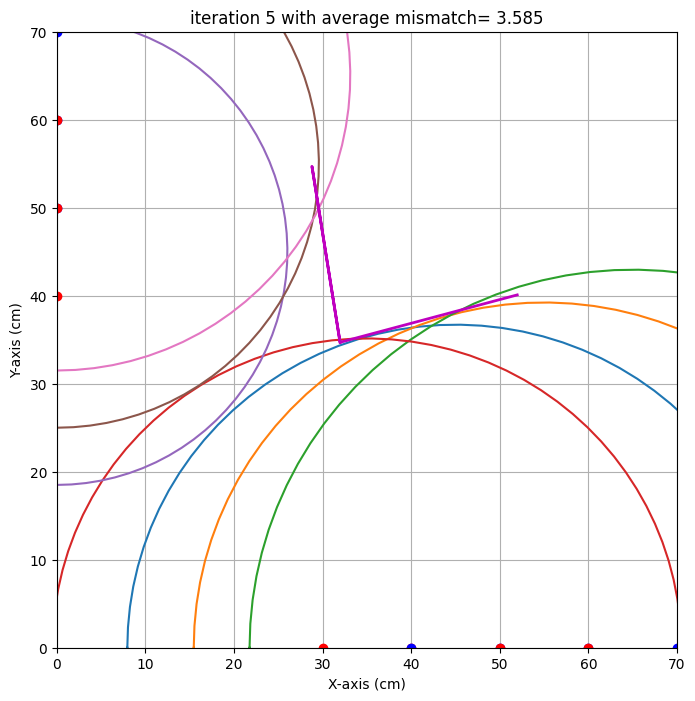

end iteration 5 with average mismatch= 3.585


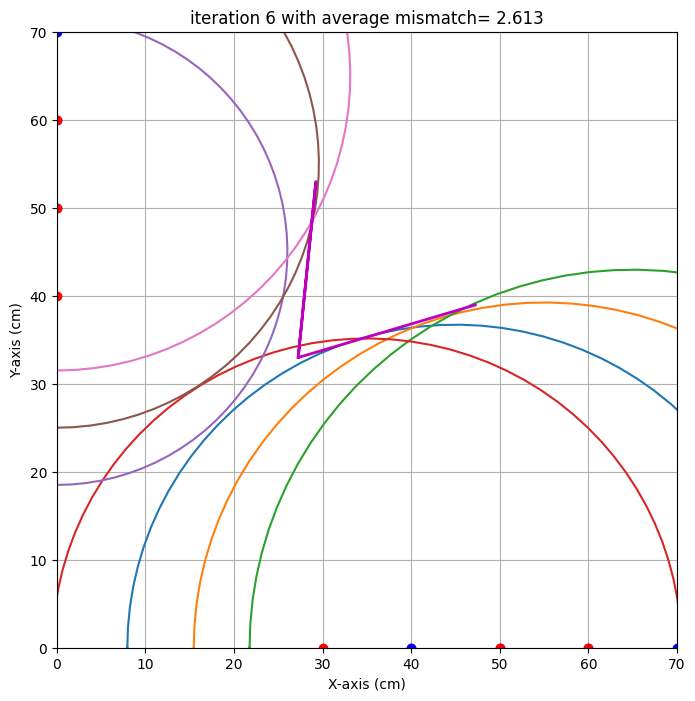

end iteration 6 with average mismatch= 2.613


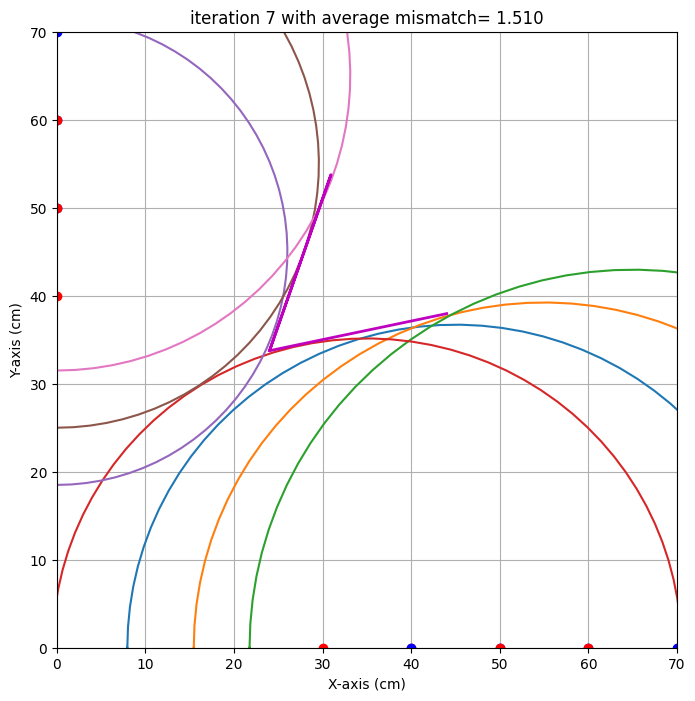

end iteration 7 with average mismatch= 1.510


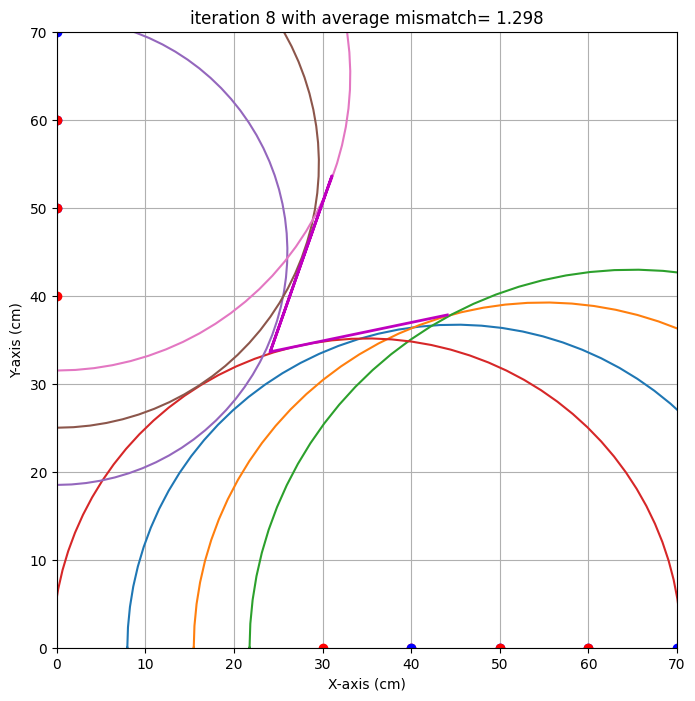

end iteration 8 with average mismatch= 1.298


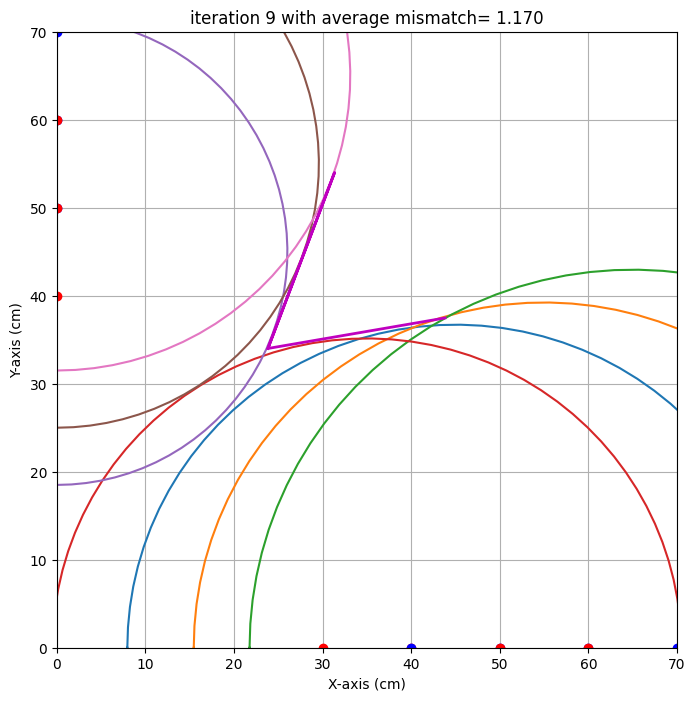

end iteration 9 with average mismatch= 1.170
end iteration 10 with average mismatch= 1.137
end iteration 11 with average mismatch= 1.136
end iteration 12 with average mismatch= 1.136
end iteration 13 with average mismatch= 1.136
end iteration 14 with average mismatch= 1.125
end iteration 15 with average mismatch= 1.124
end iteration 16 with average mismatch= 1.124
end iteration 17 with average mismatch= 1.124
end iteration 18 with average mismatch= 1.124
end iteration 19 with average mismatch= 1.124
end iteration 20 with average mismatch= 1.124
end iteration 21 with average mismatch= 1.124
end iteration 22 with average mismatch= 1.124
end iteration 23 with average mismatch= 1.124
end iteration 24 with average mismatch= 1.124
end iteration 25 with average mismatch= 1.124
end iteration 26 with average mismatch= 1.124
end iteration 27 with average mismatch= 1.124
end iteration 28 with average mismatch= 1.124
end iteration 29 with average mismatch= 1.124
Last iteration, also determine unce

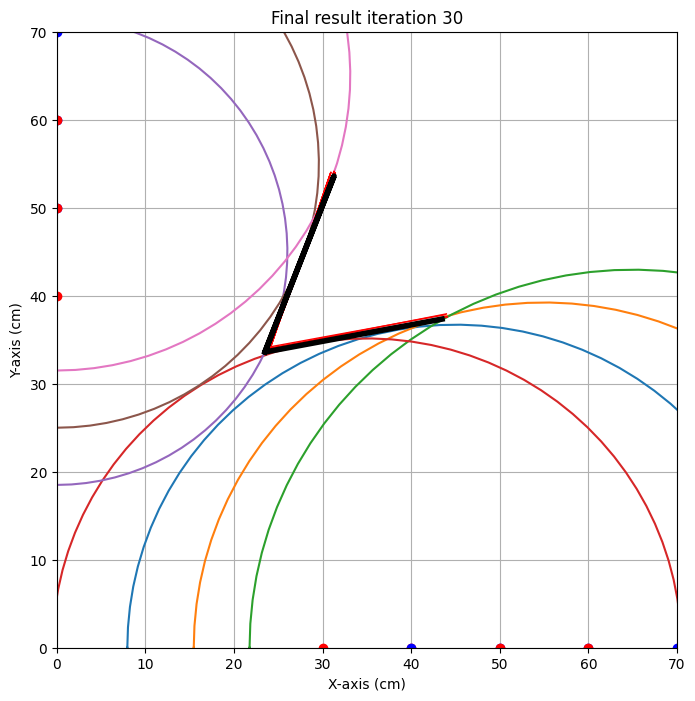

{'alpha': np.float64(10.606157575420195), 'alpha_eps': np.float64(0.5569550805484766), 'beta': np.float64(21.322961422323388), 'beta_eps': np.float64(2.4023380943918973), 'x0': np.float64(23.48205089732415), 'x0_eps': np.float64(0.5944921324333272), 'y0': np.float64(33.59942671059993), 'y0_eps': np.float64(0.5606089675979291)}
Lars
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  70   0  60  68.0
1   0  60   0  50  59.2
2   0  50   0  40  54.1
3  60   0  50   0  79.0
4  50   0  40   0  75.8
5  40   0  30   0  71.6


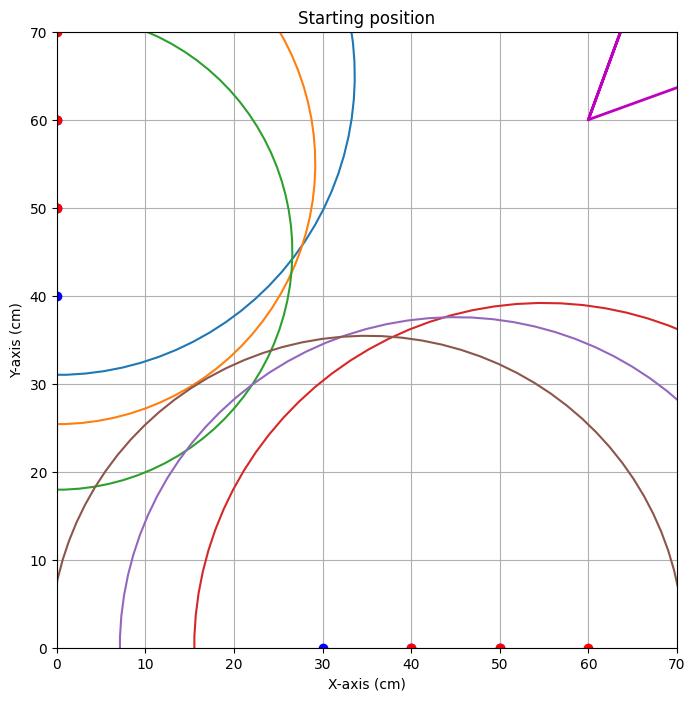


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=61.265


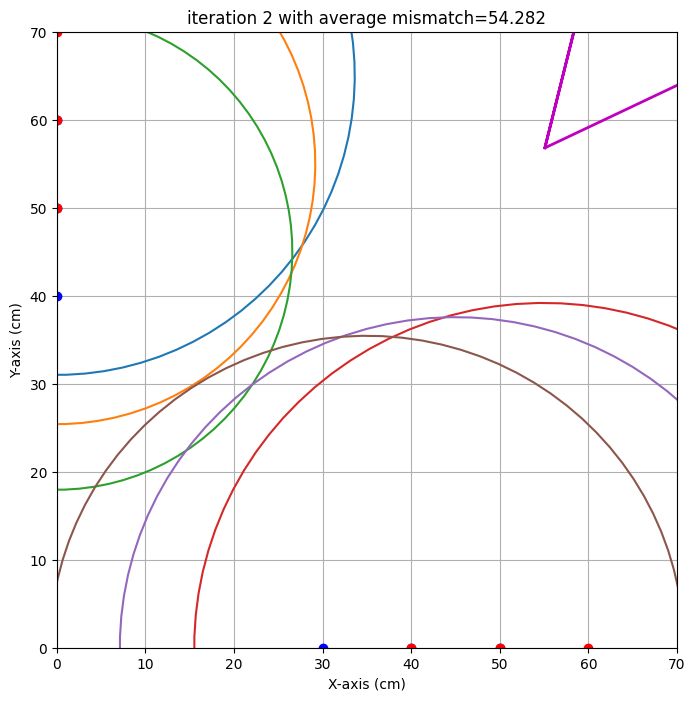

end iteration 2 with average mismatch=54.282


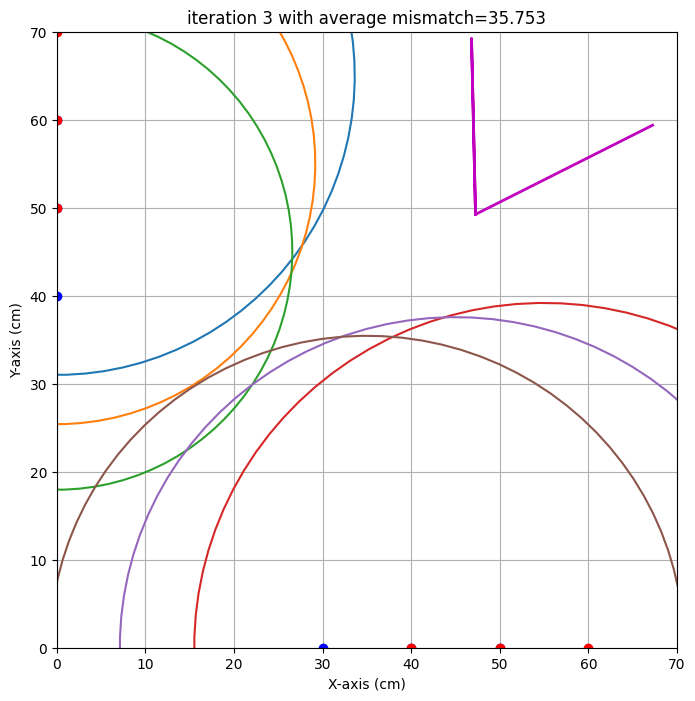

end iteration 3 with average mismatch=35.753


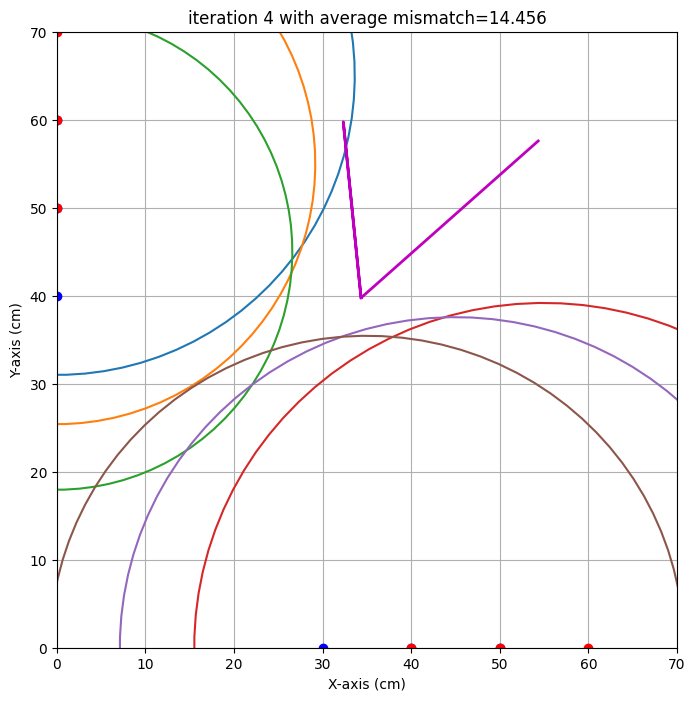

end iteration 4 with average mismatch=14.456


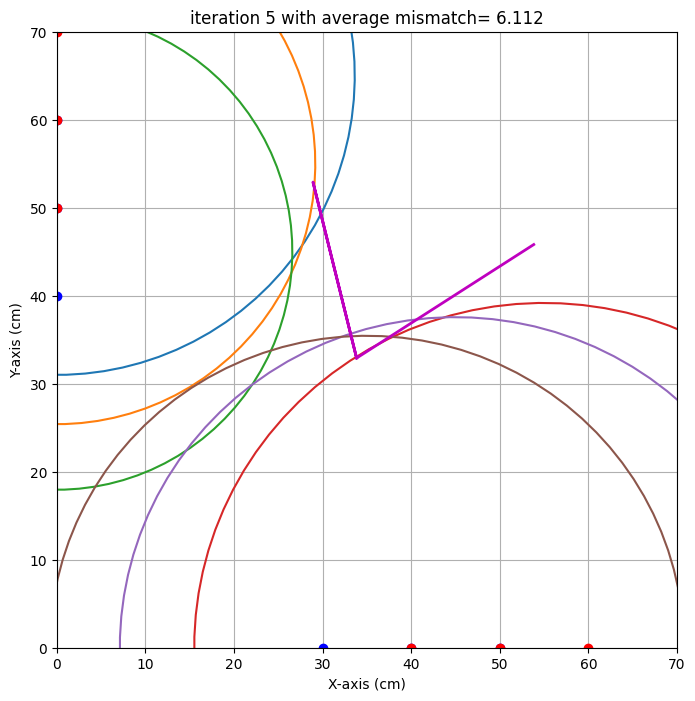

end iteration 5 with average mismatch= 6.112


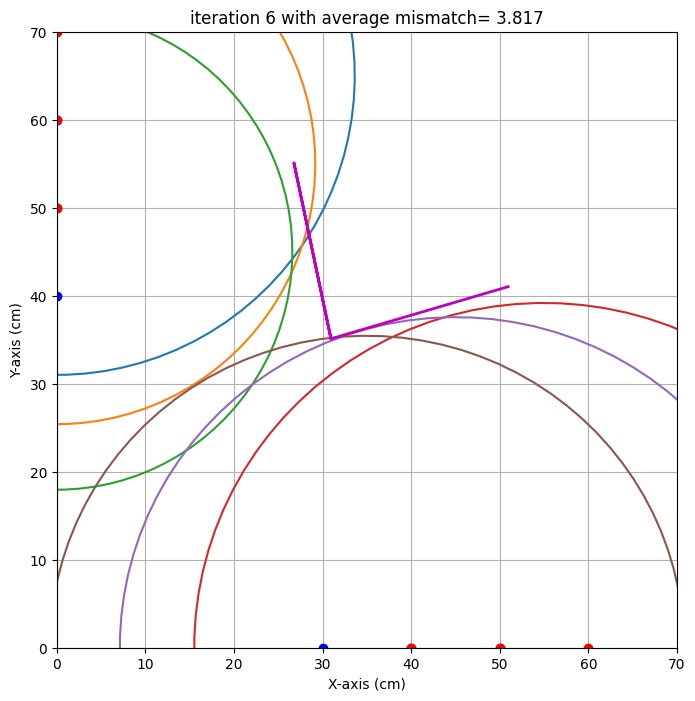

end iteration 6 with average mismatch= 3.817


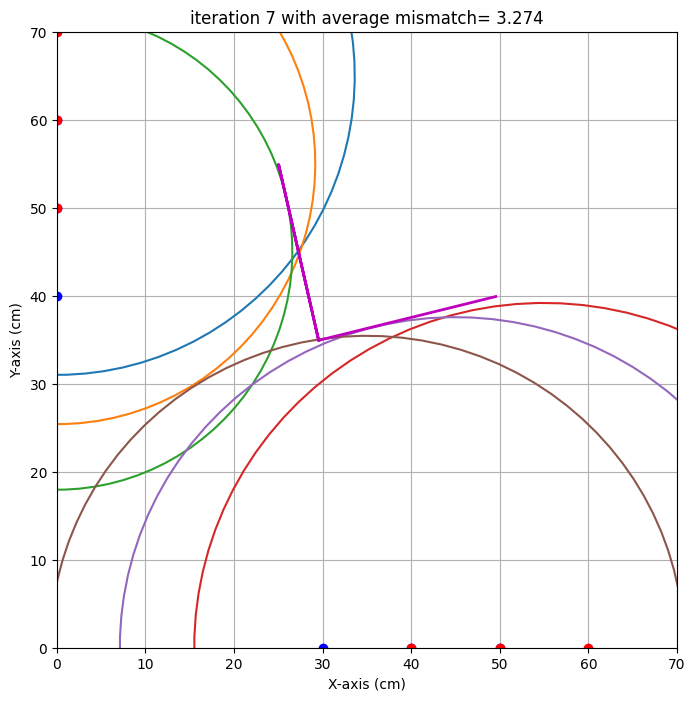

end iteration 7 with average mismatch= 3.274
end iteration 8 with average mismatch= 3.175
end iteration 9 with average mismatch= 3.028


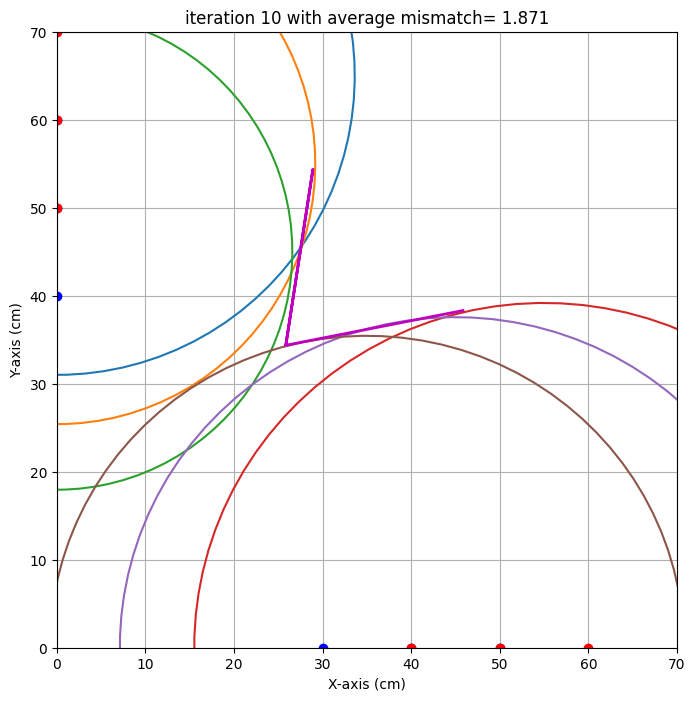

end iteration 10 with average mismatch= 1.871


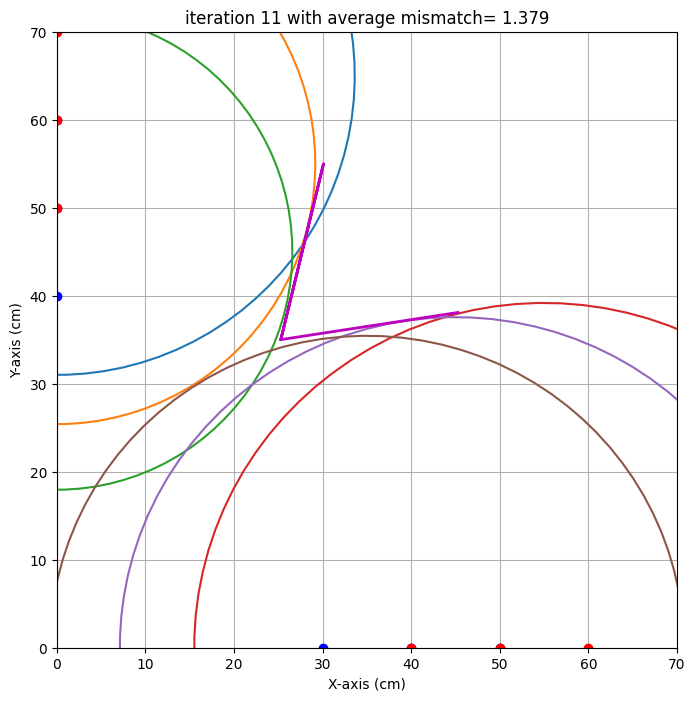

end iteration 11 with average mismatch= 1.379


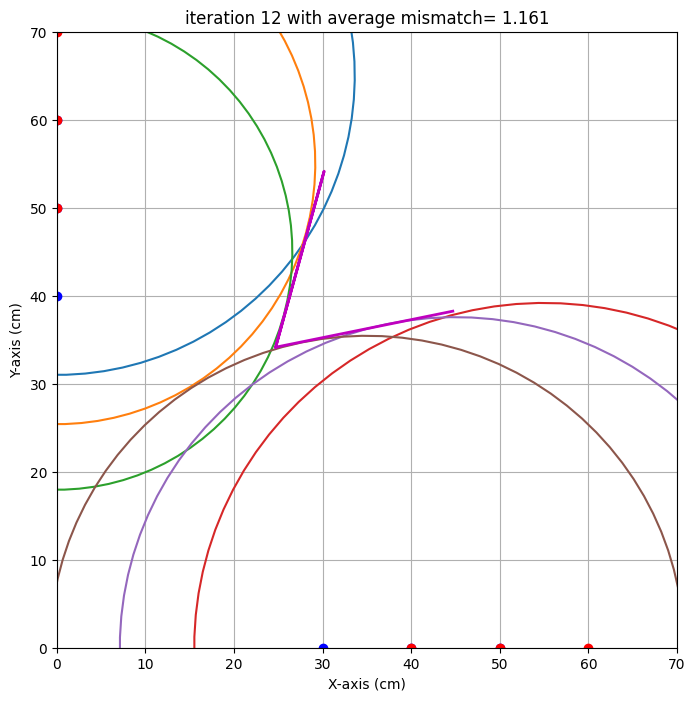

end iteration 12 with average mismatch= 1.161
end iteration 13 with average mismatch= 1.147
end iteration 14 with average mismatch= 1.144
end iteration 15 with average mismatch= 1.140
end iteration 16 with average mismatch= 1.138
end iteration 17 with average mismatch= 1.138
end iteration 18 with average mismatch= 1.138
end iteration 19 with average mismatch= 1.138
end iteration 20 with average mismatch= 1.138
end iteration 21 with average mismatch= 1.138
end iteration 22 with average mismatch= 1.138
end iteration 23 with average mismatch= 1.138
end iteration 24 with average mismatch= 1.138
end iteration 25 with average mismatch= 1.138
end iteration 26 with average mismatch= 1.138
end iteration 27 with average mismatch= 1.112
end iteration 28 with average mismatch= 1.080
end iteration 29 with average mismatch= 1.073
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.072
#################

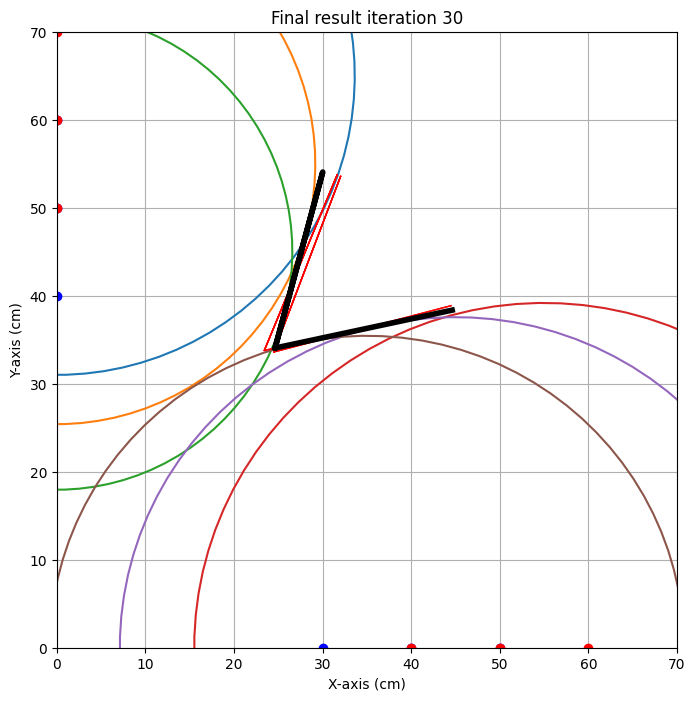

{'alpha': np.float64(12.1438099942084), 'alpha_eps': np.float64(2.598874570005483), 'beta': np.float64(15.067631004700662), 'beta_eps': np.float64(7.330210988337516), 'x0': np.float64(24.62830857567), 'x0_eps': np.float64(1.2113012178052713), 'y0': np.float64(34.05736224264907), 'y0_eps': np.float64(0.4546081881629007)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Elisabeth 
x0 target is : 26.5. Gevonden waarde: 27.8 cm met een standaardafwijking van 0.8 cm 
y0 target is : 34.5. Gevonden waarde: 34.0 cm met een standaardafwijking van 0.6 cm 
alpha target is : 13.0. Gevonden waarde: 14.3 graden met een standaardafwijking van 2.3 graad 
beta target is : 13.0. Gevonden waarde: -4.5 graden met een standaardafwijking van 3.6 graad 

Oscar 
x0 target is : 26.5. Gevonden waarde: 23.5 cm met een standaardafwijking van 0.6 cm 
y0 target is : 34.5. Gevonden waarde: 33.6 cm met een standaardafwijking van 0.6 cm 
alpha target is : 13.0. Gevonden waarde: 10.6 graden met een standaardafwijking van 0.6 graad 
beta target is : 13.0. Gevonden waarde: 21.3 graden met een standaardafwijking van 2.4 graad 

Lars 
x0 target is : 26.5. Gevonden waarde: 24.6 cm met een standaardafwijking van 1.2 cm 
y0 target is : 34.5. Gevonden waarde: 34.1 cm met een standaardafwijking van 0.5 cm 
alpha target is : 13.0. Gevonden waarde: 12.1 graden met een standaardafwijking van 2.

## Opdracht 8: Iteratie1+ 14:41
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

## Figuur: iteratie 1 ![Image](Iteratie1.jpeg)
## Figuur: iteratie 2 ![Image](Iteratie2.jpeg)
## Figuur: iteratie 3 ![Image](iteratie3.jpeg)


## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  75.2
1  45   0  55   0  77.6
2  50   0  60   0  79.4
3  35   0  45   0  72.6
4  30   0  40   0  72.0
5   0  40   0  50  54.0
6   0  45   0  55  56.5
7   0  50   0  60  60.6
8   0  35   0  45  55.6
9   0  55   0  65  67.8


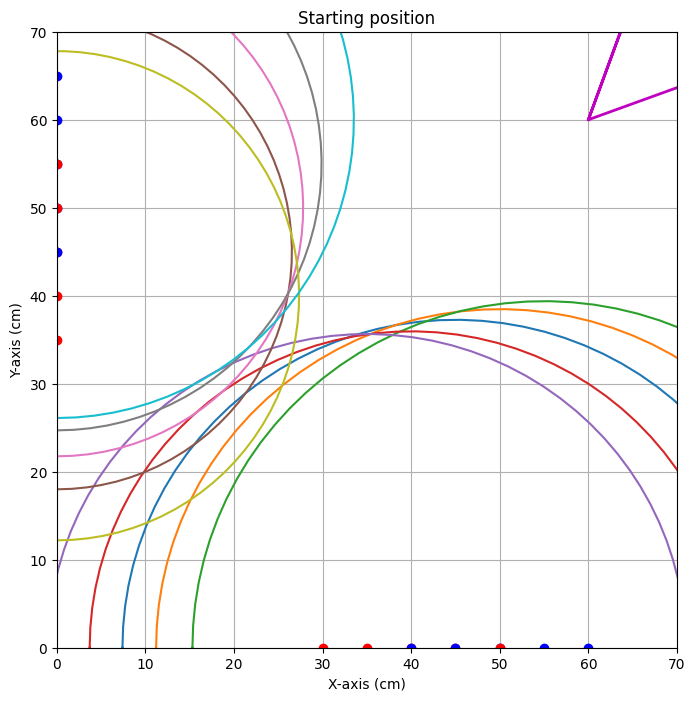


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=62.804


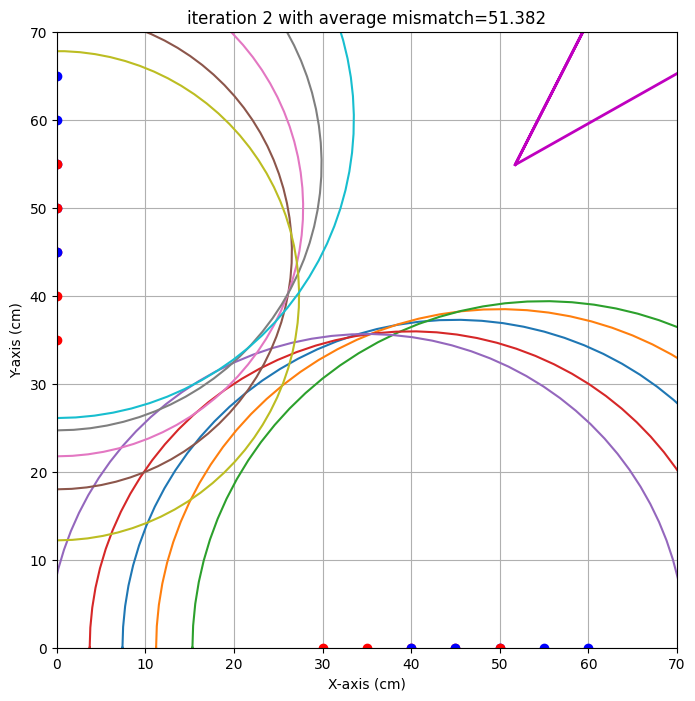

end iteration 2 with average mismatch=51.382


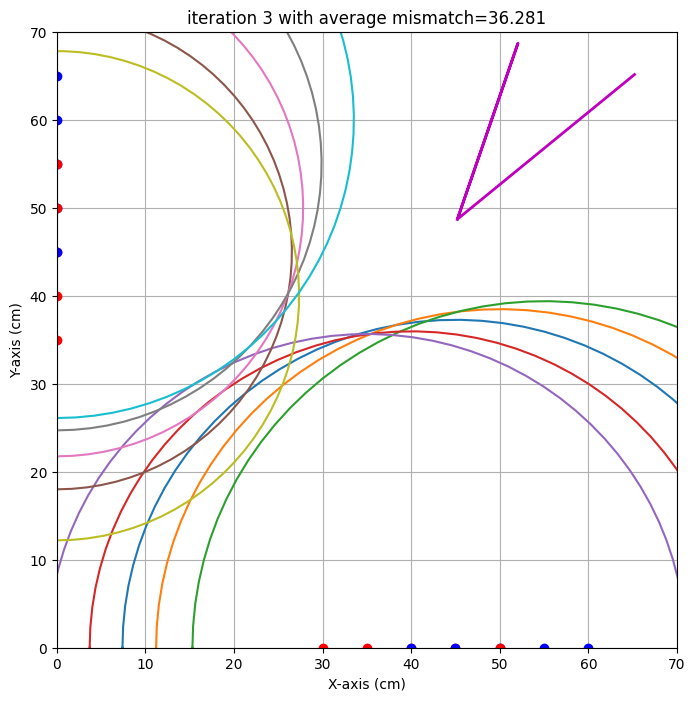

end iteration 3 with average mismatch=36.281


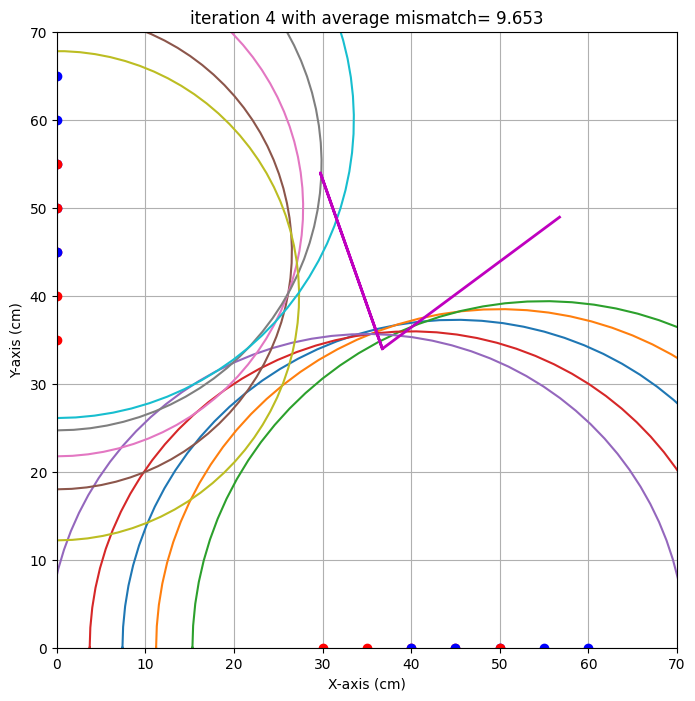

end iteration 4 with average mismatch= 9.653


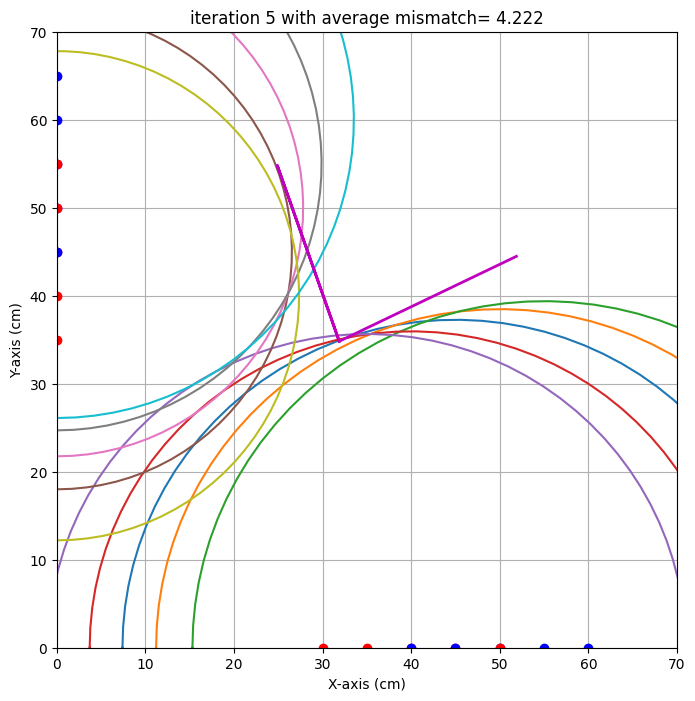

end iteration 5 with average mismatch= 4.222


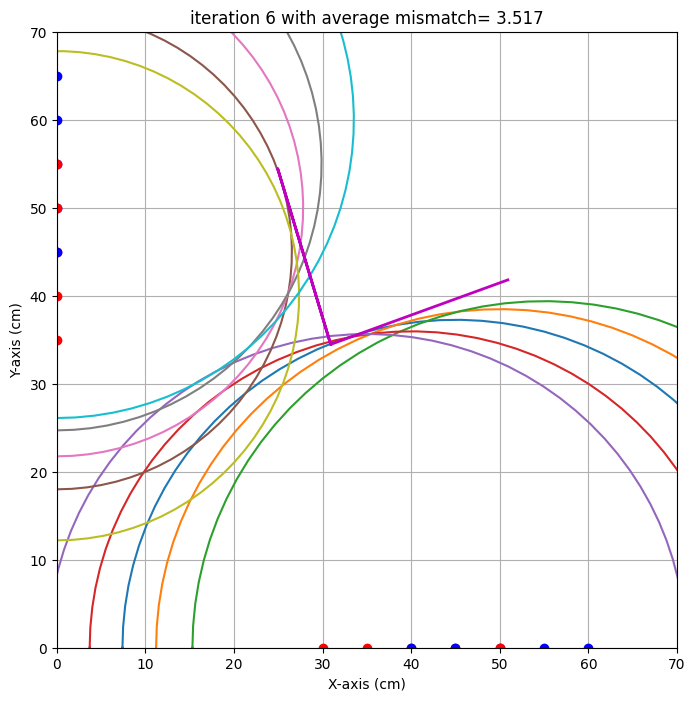

end iteration 6 with average mismatch= 3.517


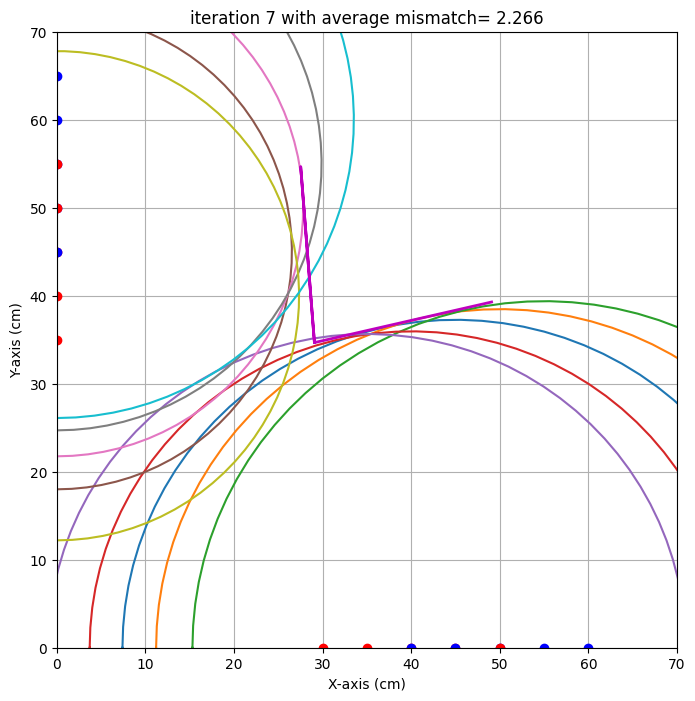

end iteration 7 with average mismatch= 2.266


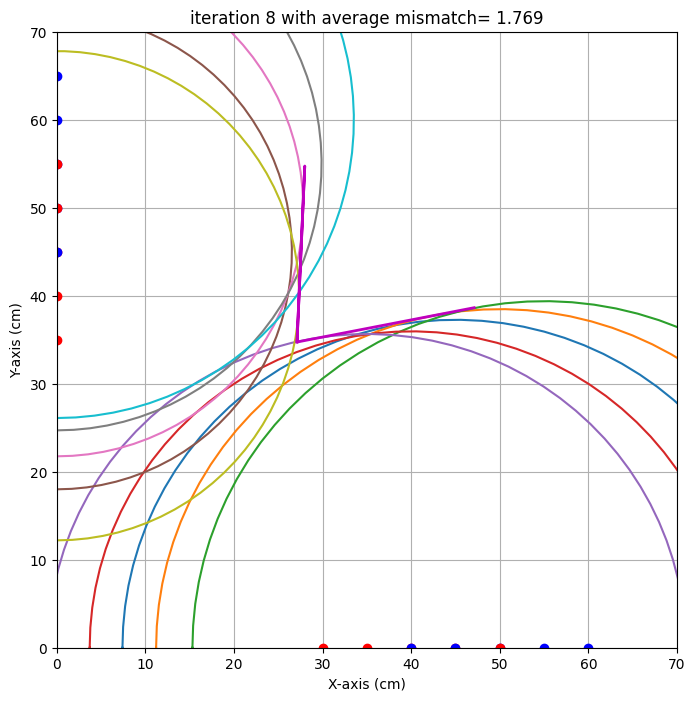

end iteration 8 with average mismatch= 1.769
end iteration 9 with average mismatch= 1.686
end iteration 10 with average mismatch= 1.648
end iteration 11 with average mismatch= 1.636
end iteration 12 with average mismatch= 1.632
end iteration 13 with average mismatch= 1.631
end iteration 14 with average mismatch= 1.631
end iteration 15 with average mismatch= 1.631
end iteration 16 with average mismatch= 1.631
end iteration 17 with average mismatch= 1.631
end iteration 18 with average mismatch= 1.631
end iteration 19 with average mismatch= 1.631
end iteration 20 with average mismatch= 1.631
end iteration 21 with average mismatch= 1.631
end iteration 22 with average mismatch= 1.631
end iteration 23 with average mismatch= 1.631
end iteration 24 with average mismatch= 1.631
end iteration 25 with average mismatch= 1.631
end iteration 26 with average mismatch= 1.631
end iteration 27 with average mismatch= 1.631
end iteration 28 with average mismatch= 1.631
end iteration 29 with average mismat

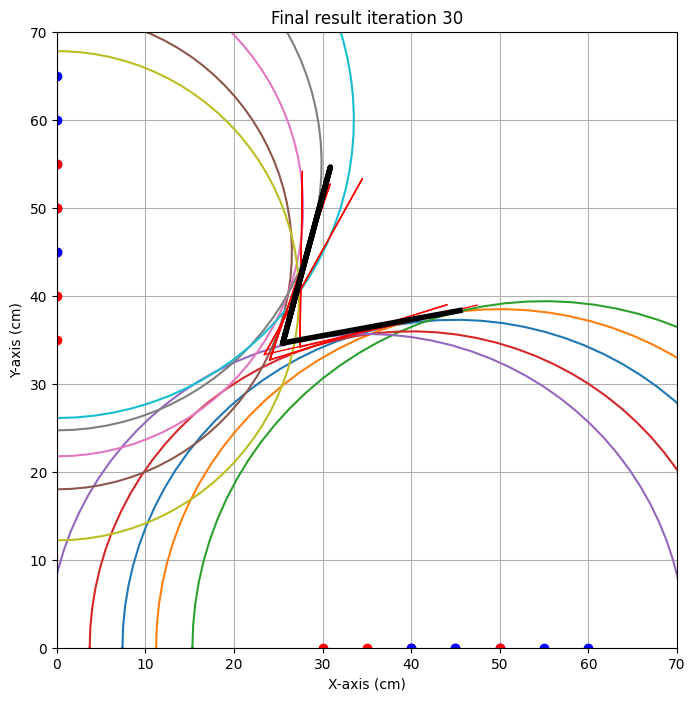

{'alpha': np.float64(10.453732014601224), 'alpha_eps': np.float64(6.940006455789691), 'beta': np.float64(15.037200316911264), 'beta_eps': np.float64(14.24730987342291), 'x0': np.float64(25.506087356037444), 'x0_eps': np.float64(2.087786083606069), 'y0': np.float64(34.6275825864438), 'y0_eps': np.float64(1.9239277646929054)}
locatie 2
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  50.0   0.0  65.0   0.0  93.5
1  52.5   0.0  67.5   0.0  95.1
2  55.0   0.0  70.0   0.0  97.0
3  47.5   0.0  62.5   0.0  91.0
4  45.0   0.0  60.0   0.0  90.3
5   0.0  50.0   0.0  65.0  67.8
6   0.0  52.5   0.0  67.5  68.1
7   0.0  55.0   0.0  70.0  70.7
8   0.0  47.5   0.0  62.5  68.0
9   0.0  45.0   0.0  60.0  67.1


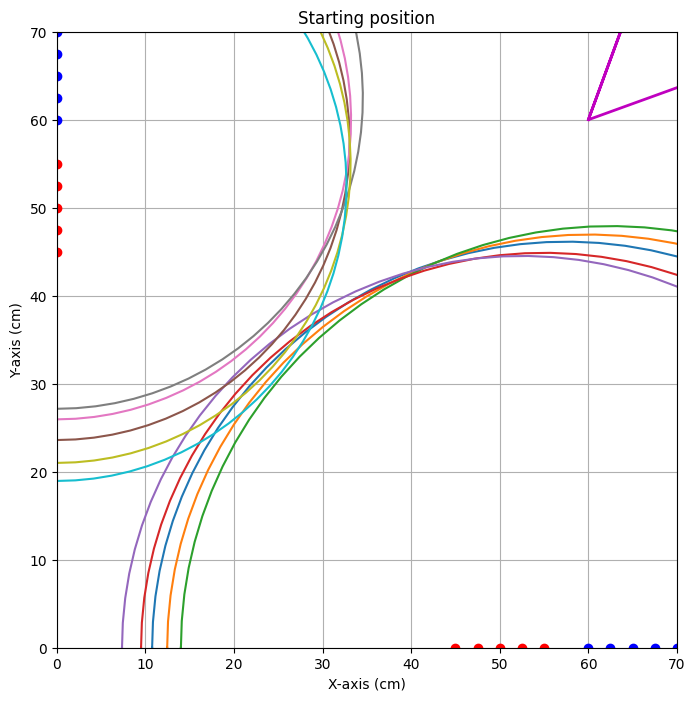


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.882


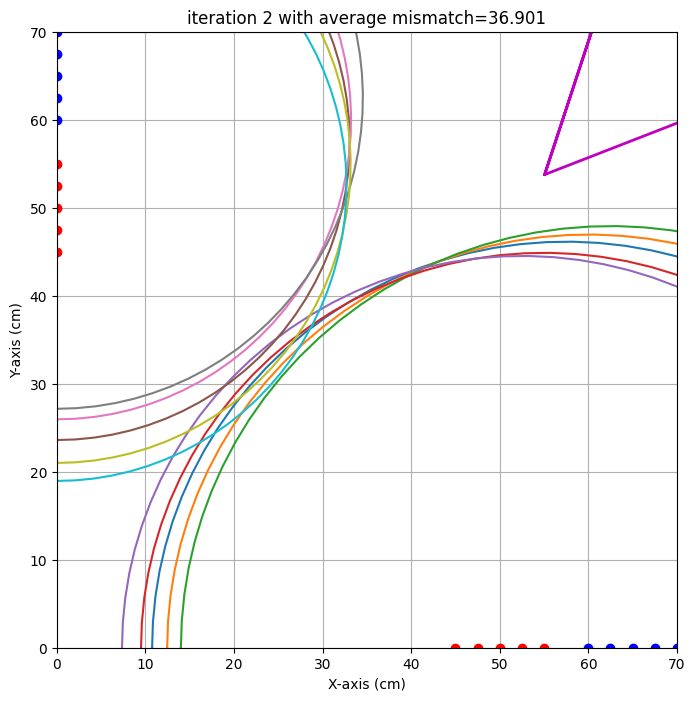

end iteration 2 with average mismatch=36.901


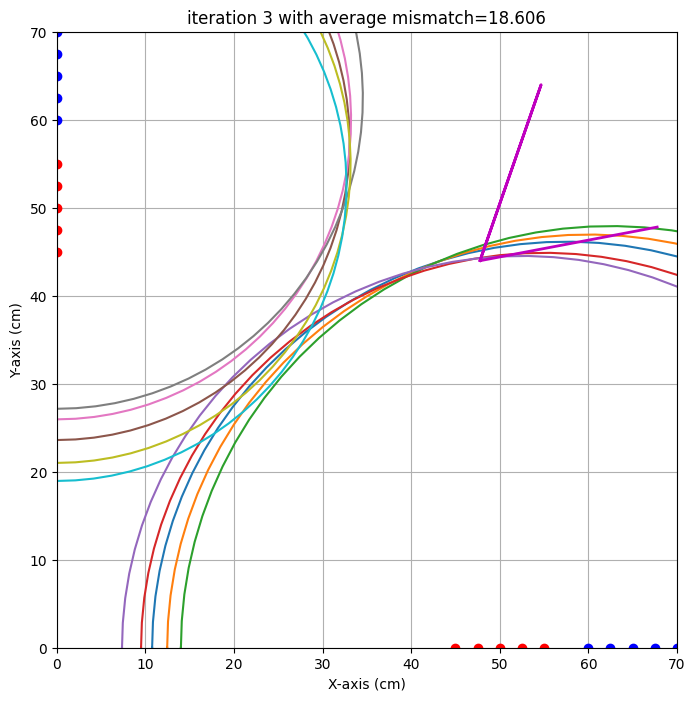

end iteration 3 with average mismatch=18.606


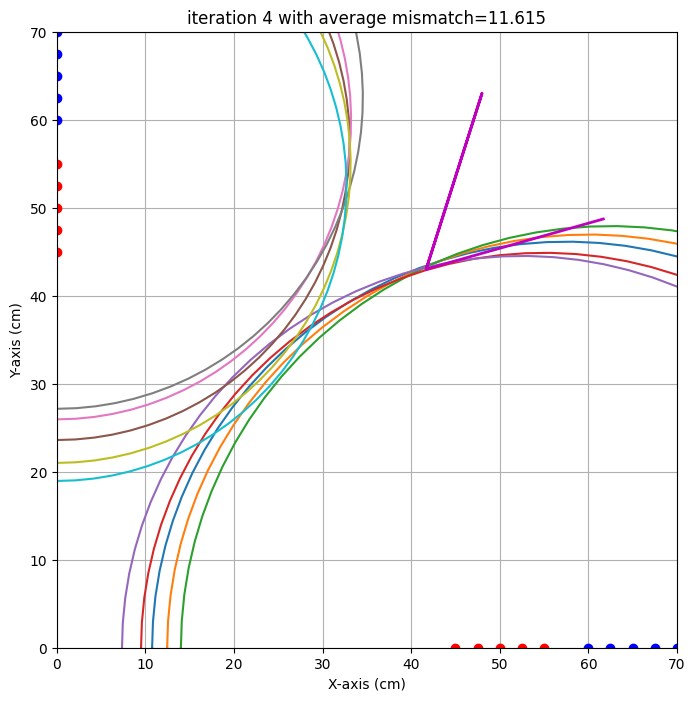

end iteration 4 with average mismatch=11.615


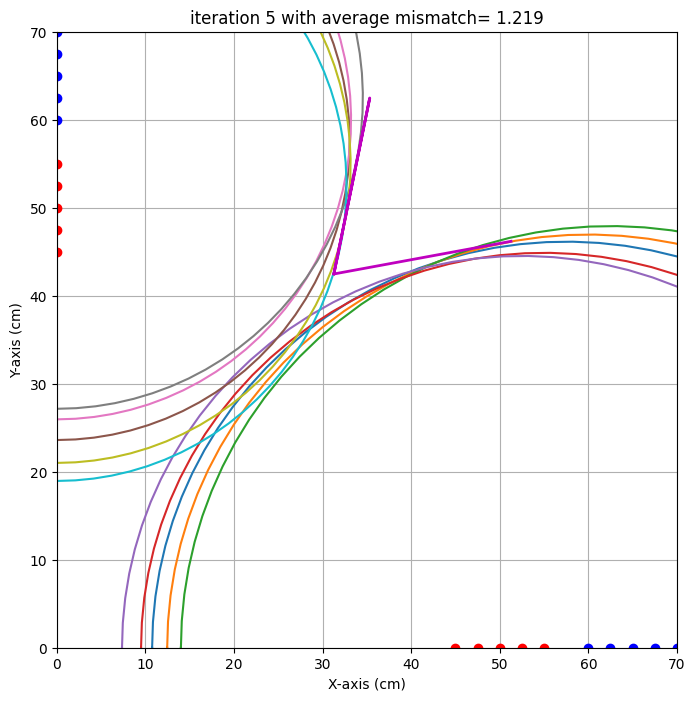

end iteration 5 with average mismatch= 1.219
end iteration 6 with average mismatch= 1.144
end iteration 7 with average mismatch= 1.141


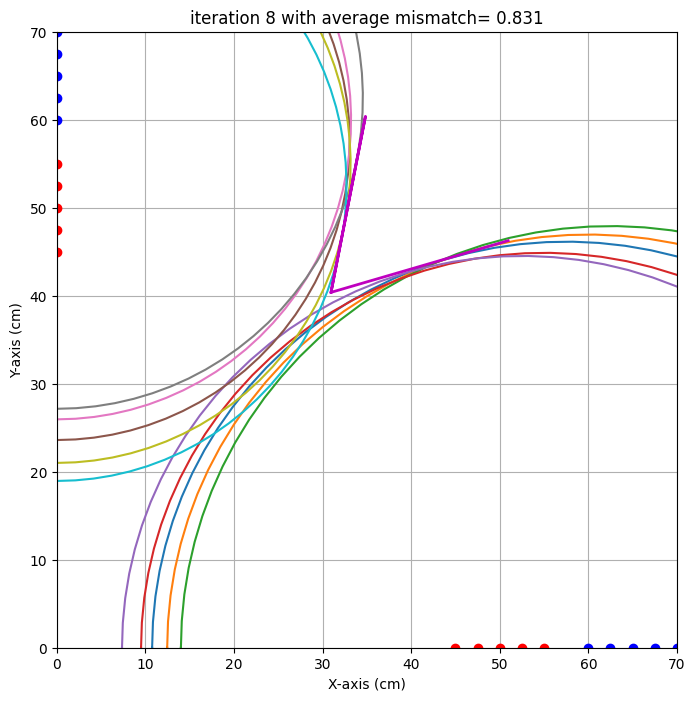

end iteration 8 with average mismatch= 0.831
end iteration 9 with average mismatch= 0.780


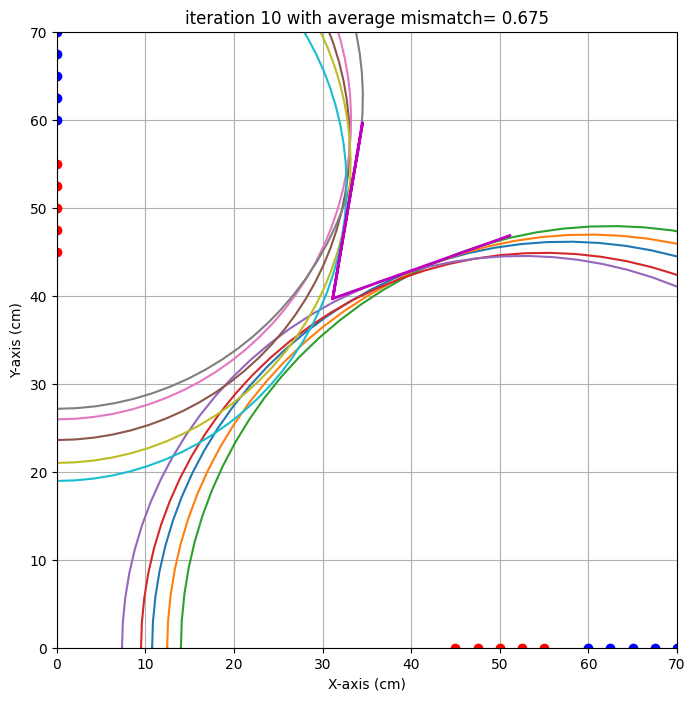

end iteration 10 with average mismatch= 0.675


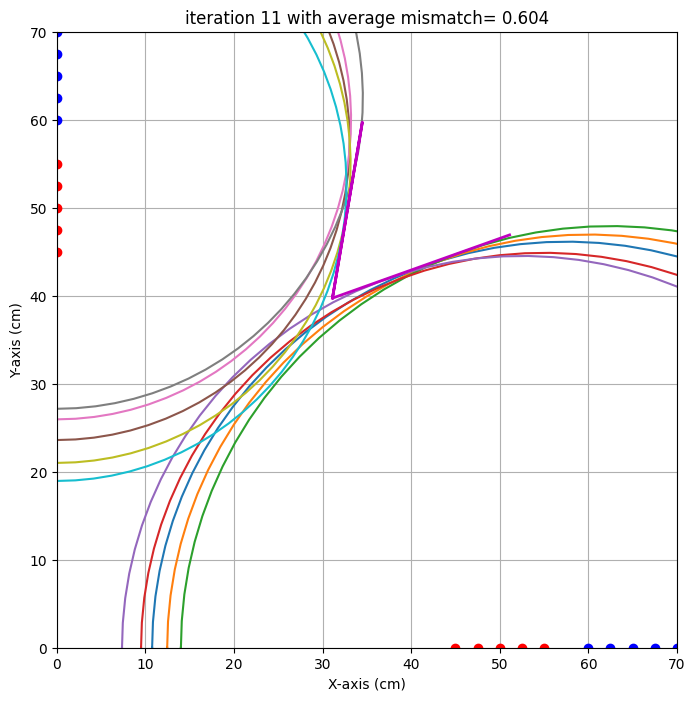

end iteration 11 with average mismatch= 0.604
end iteration 12 with average mismatch= 0.591
end iteration 13 with average mismatch= 0.589
end iteration 14 with average mismatch= 0.589
end iteration 15 with average mismatch= 0.589
end iteration 16 with average mismatch= 0.589
end iteration 17 with average mismatch= 0.589
end iteration 18 with average mismatch= 0.589
end iteration 19 with average mismatch= 0.589
end iteration 20 with average mismatch= 0.589
end iteration 21 with average mismatch= 0.589
end iteration 22 with average mismatch= 0.589
end iteration 23 with average mismatch= 0.589
end iteration 24 with average mismatch= 0.589
end iteration 25 with average mismatch= 0.589
end iteration 26 with average mismatch= 0.589
end iteration 27 with average mismatch= 0.589
end iteration 28 with average mismatch= 0.589
end iteration 29 with average mismatch= 0.589
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

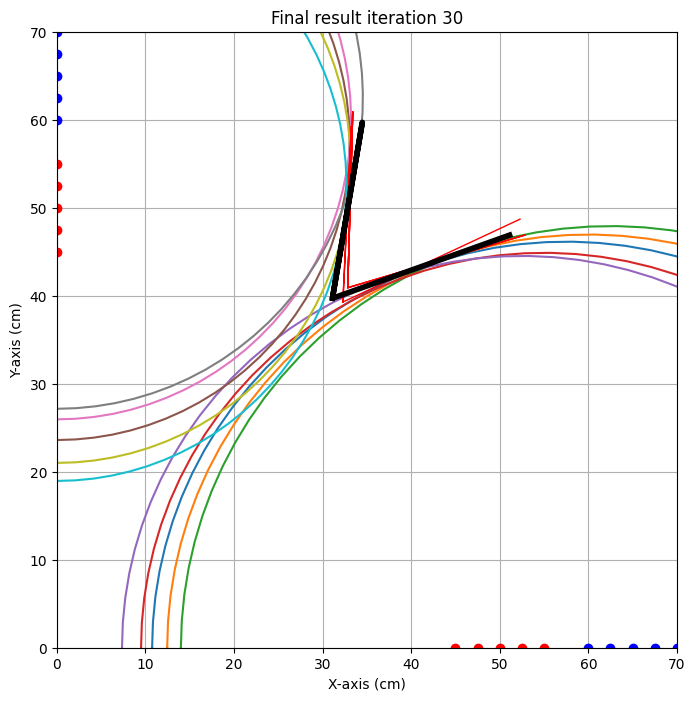

{'alpha': np.float64(19.743773543758486), 'alpha_eps': np.float64(5.4693718388350305), 'beta': np.float64(9.589087851699587), 'beta_eps': np.float64(7.974004562796631), 'x0': np.float64(31.106093555209483), 'x0_eps': np.float64(1.7310918812106166), 'y0': np.float64(39.708379764078444), 'y0_eps': np.float64(1.2027383512215195)}
locatie 3
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  65   0  92.4
1  55   0  70   0  98.0
2  45   0  60   0  89.6
3   0  50   0  65  67.3
4   0  55   0  70  69.6
5   0  45   0  60  65.5


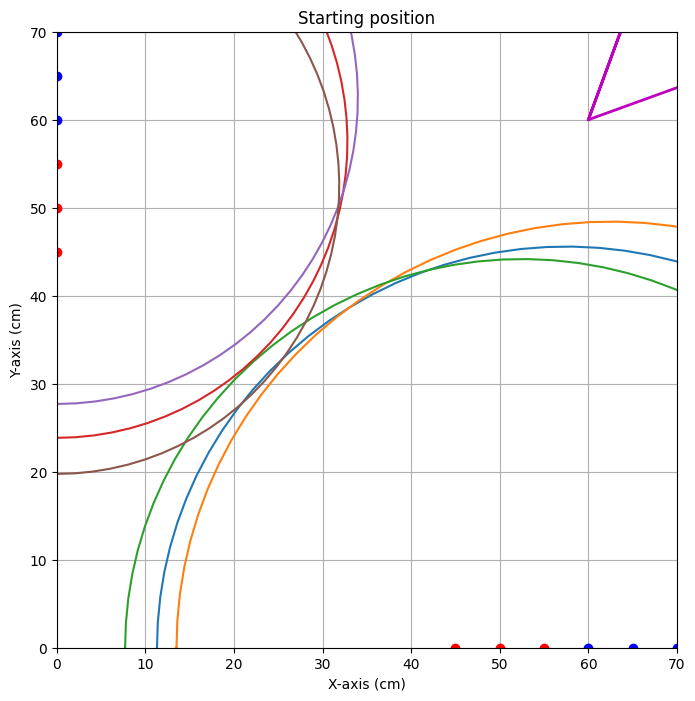


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=46.406


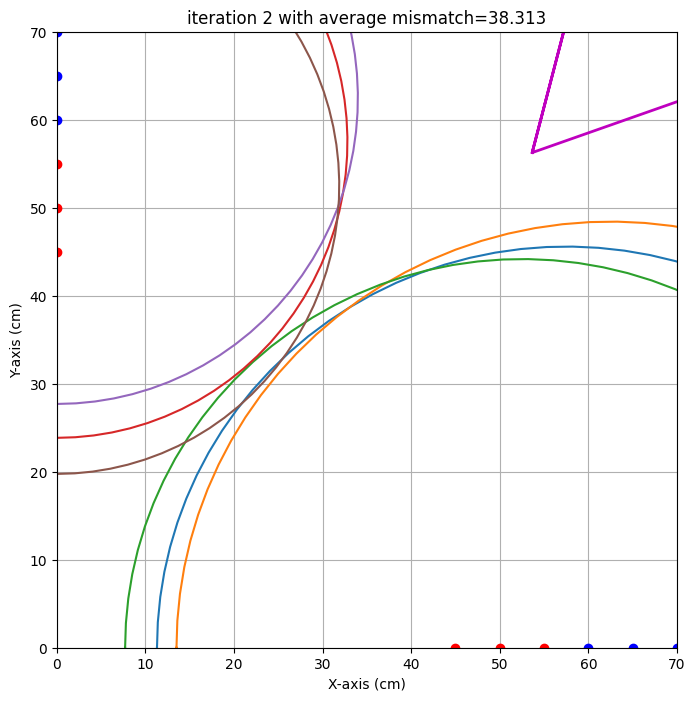

end iteration 2 with average mismatch=38.313


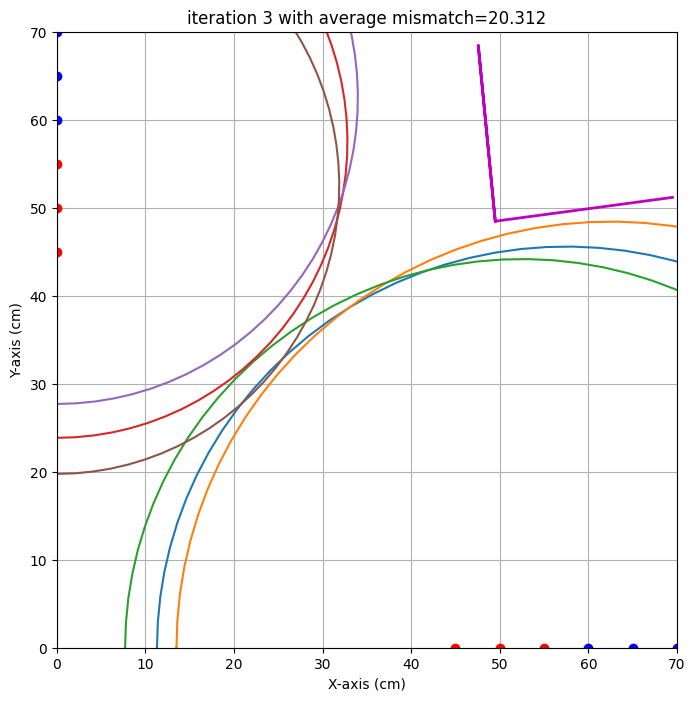

end iteration 3 with average mismatch=20.312


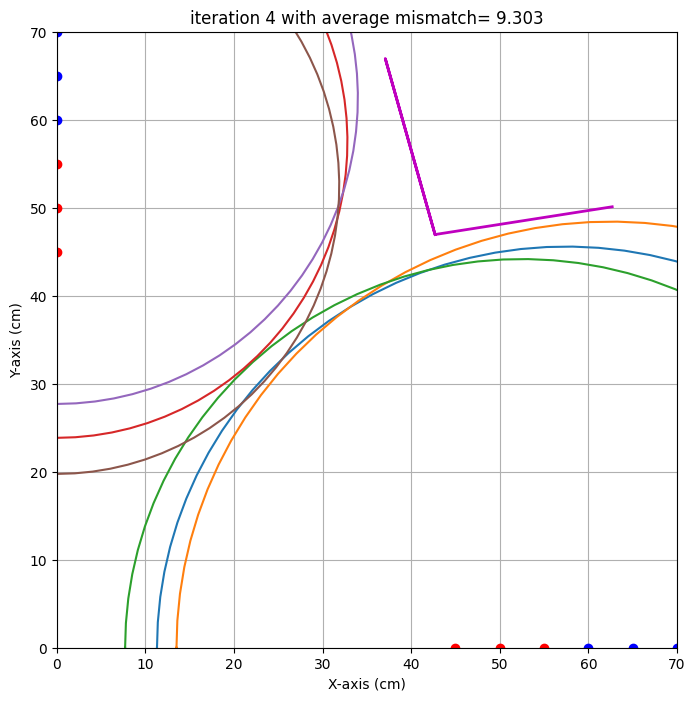

end iteration 4 with average mismatch= 9.303


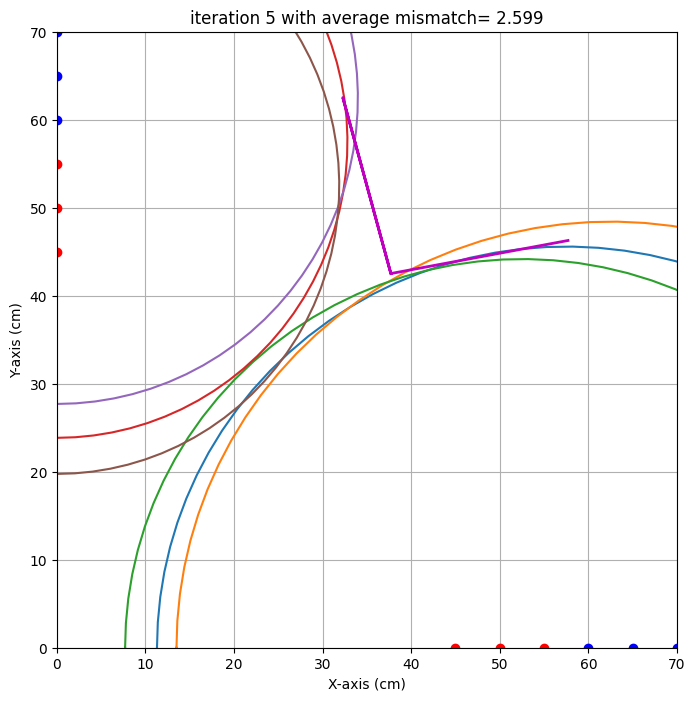

end iteration 5 with average mismatch= 2.599
end iteration 6 with average mismatch= 2.598


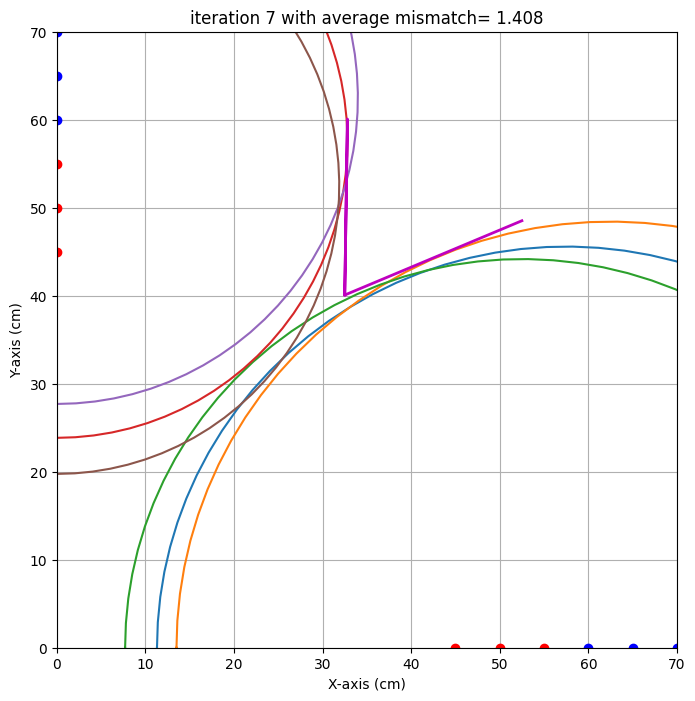

end iteration 7 with average mismatch= 1.408


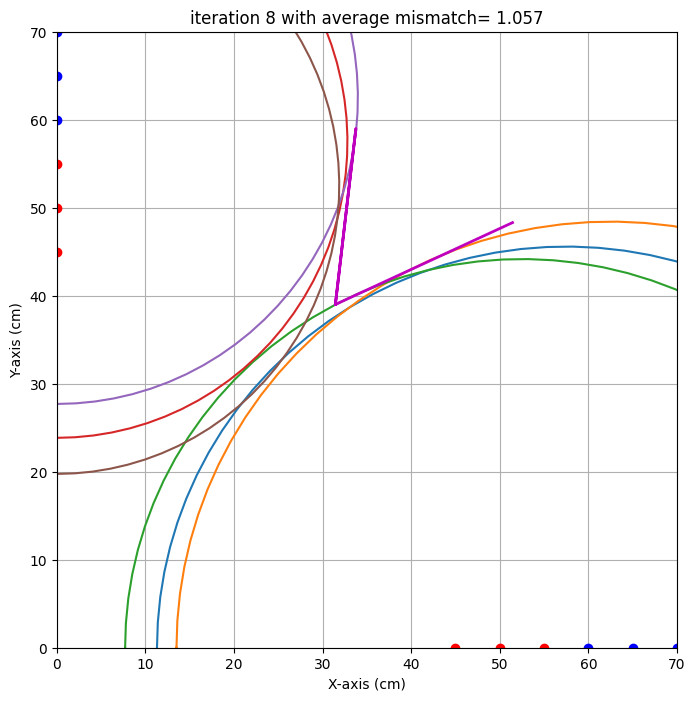

end iteration 8 with average mismatch= 1.057


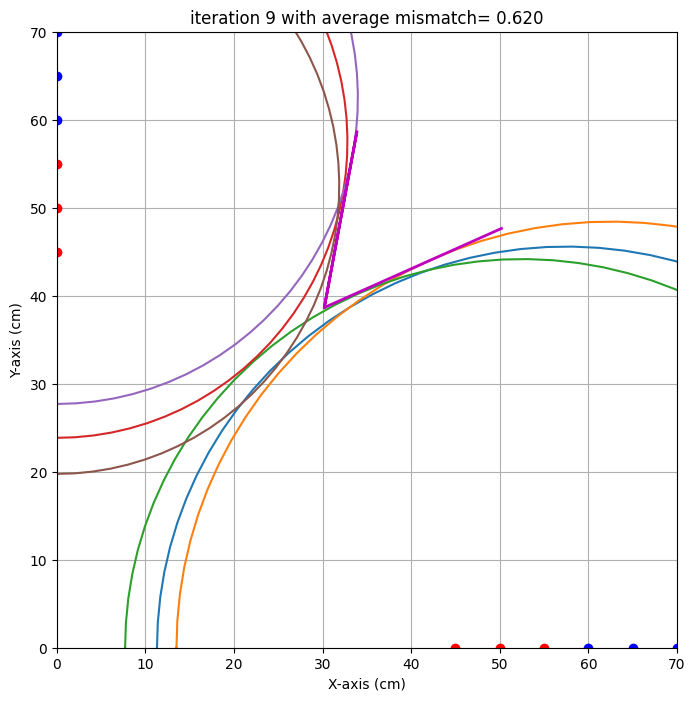

end iteration 9 with average mismatch= 0.620
end iteration 10 with average mismatch= 0.581
end iteration 11 with average mismatch= 0.525
end iteration 12 with average mismatch= 0.506
end iteration 13 with average mismatch= 0.504
end iteration 14 with average mismatch= 0.504
end iteration 15 with average mismatch= 0.481
end iteration 16 with average mismatch= 0.465
end iteration 17 with average mismatch= 0.451
end iteration 18 with average mismatch= 0.450
end iteration 19 with average mismatch= 0.449
end iteration 20 with average mismatch= 0.449
end iteration 21 with average mismatch= 0.449
end iteration 22 with average mismatch= 0.449
end iteration 23 with average mismatch= 0.449
end iteration 24 with average mismatch= 0.449
end iteration 25 with average mismatch= 0.449
end iteration 26 with average mismatch= 0.449
end iteration 27 with average mismatch= 0.449
end iteration 28 with average mismatch= 0.449
end iteration 29 with average mismatch= 0.449
Last iteration, also determine unce

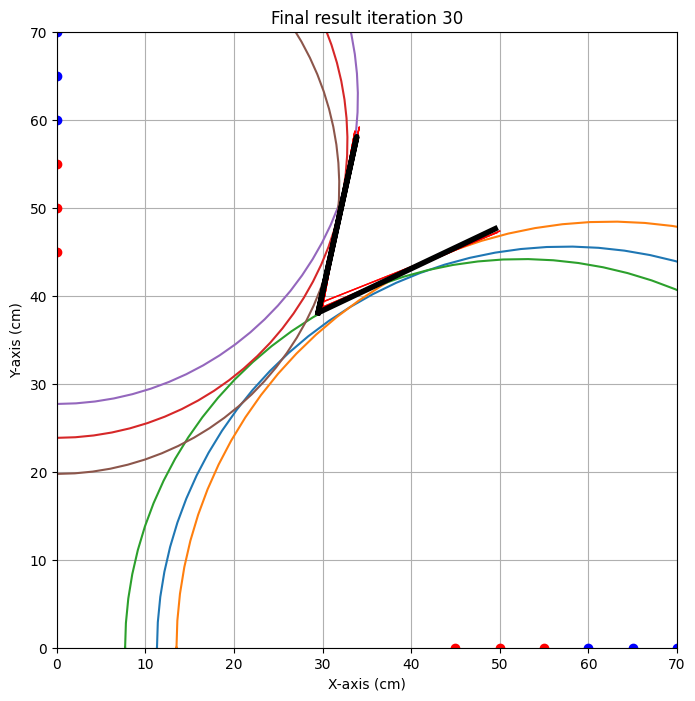

{'alpha': np.float64(25.500042106655556), 'alpha_eps': np.float64(3.6892817687541957), 'beta': np.float64(12.312407352829283), 'beta_eps': np.float64(1.9658277823032861), 'x0': np.float64(29.488760850103883), 'x0_eps': np.float64(0.5047801118945969), 'y0': np.float64(38.07075855543463), 'y0_eps': np.float64(1.0990762023998073)}
locatie 4
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  50   0  81.1
1  30   0  45   0  78.4
2  25   0  40   0  78.0
3   0  50   0  65  51.6
4   0  55   0  70  54.4
5   0  45   0  60  50.6


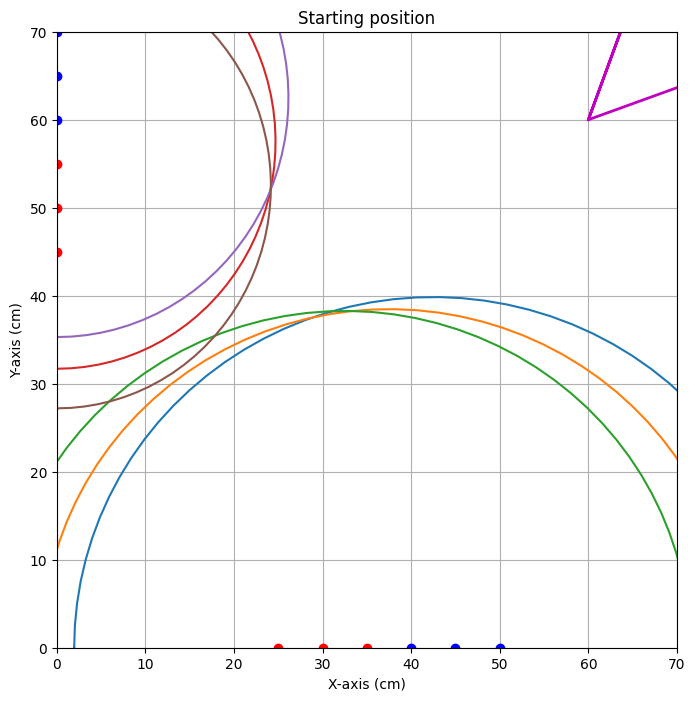


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=65.029


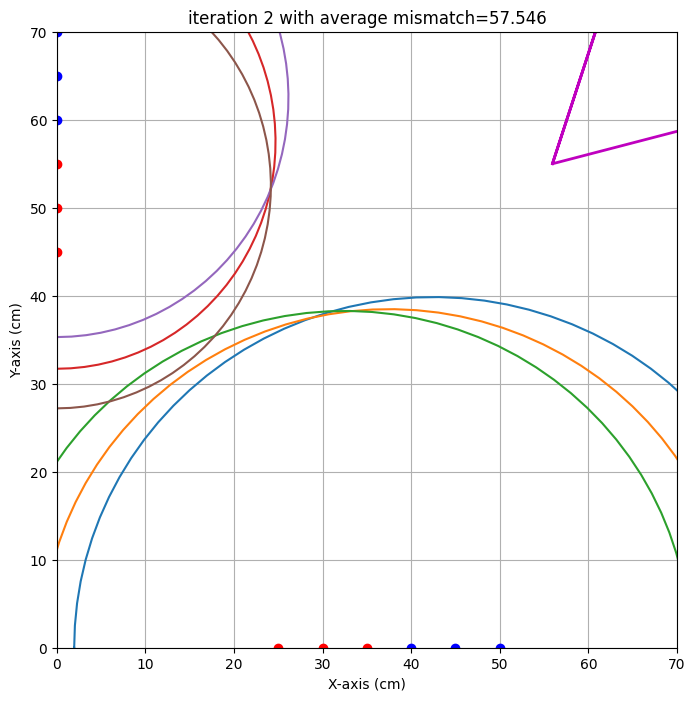

end iteration 2 with average mismatch=57.546


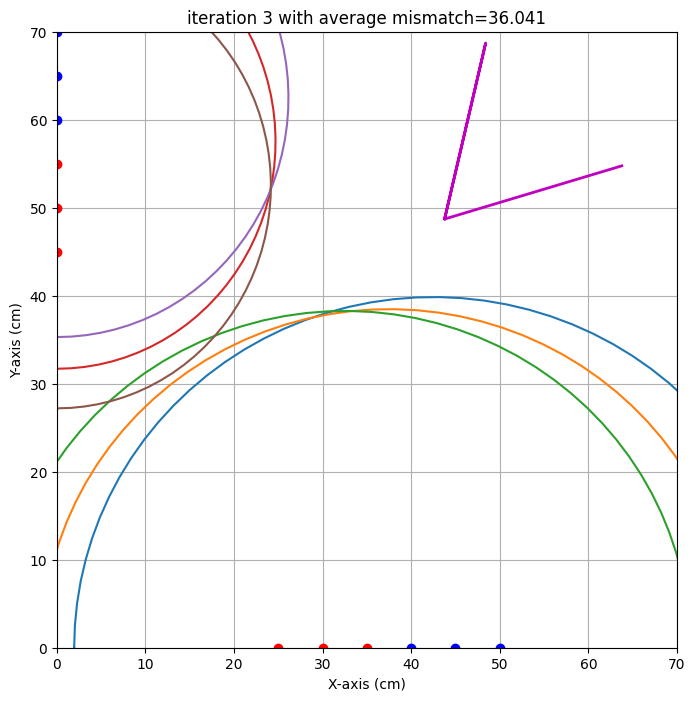

end iteration 3 with average mismatch=36.041


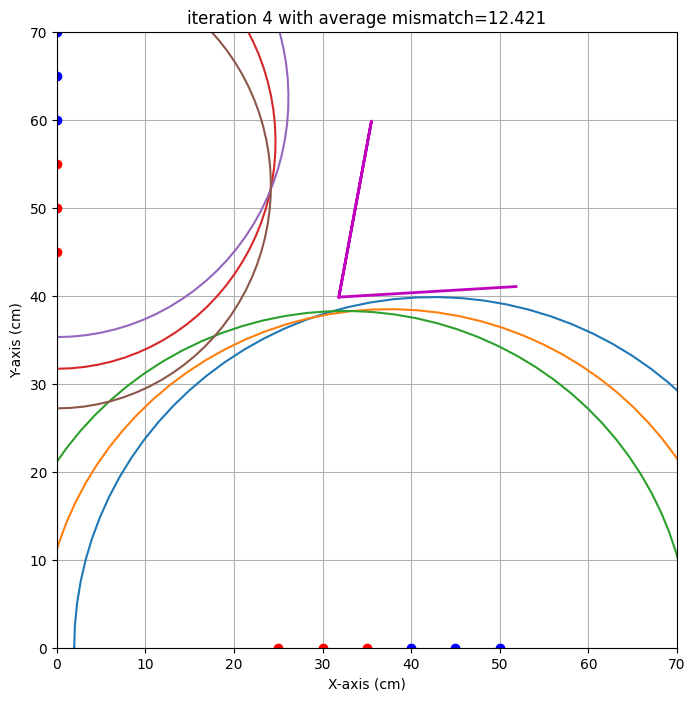

end iteration 4 with average mismatch=12.421


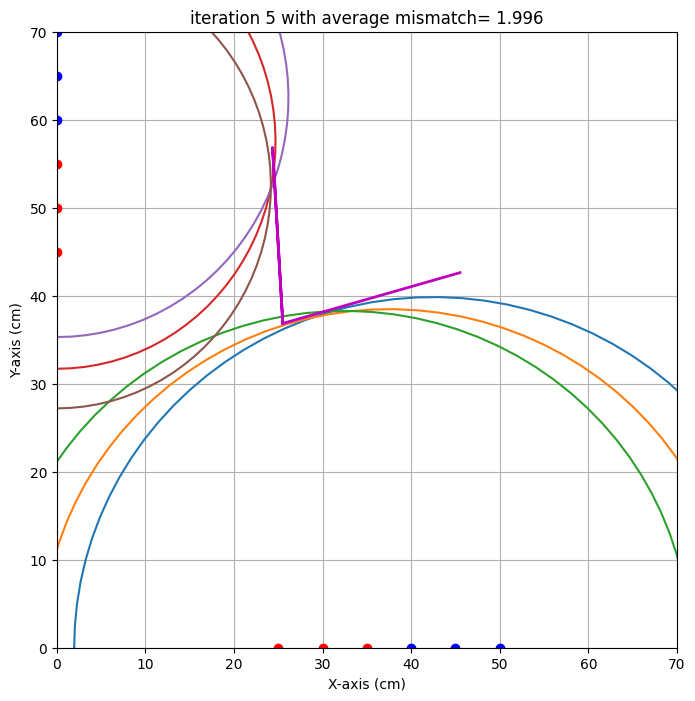

end iteration 5 with average mismatch= 1.996


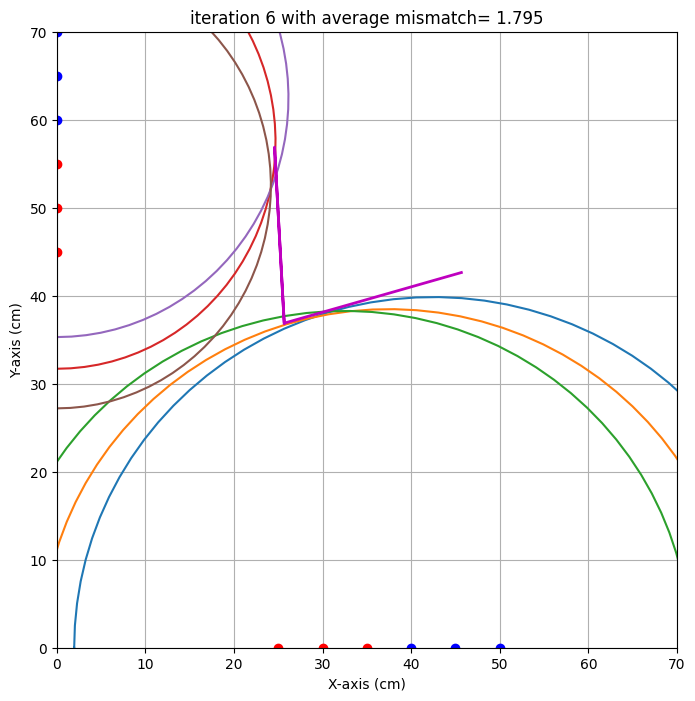

end iteration 6 with average mismatch= 1.795
end iteration 7 with average mismatch= 1.795


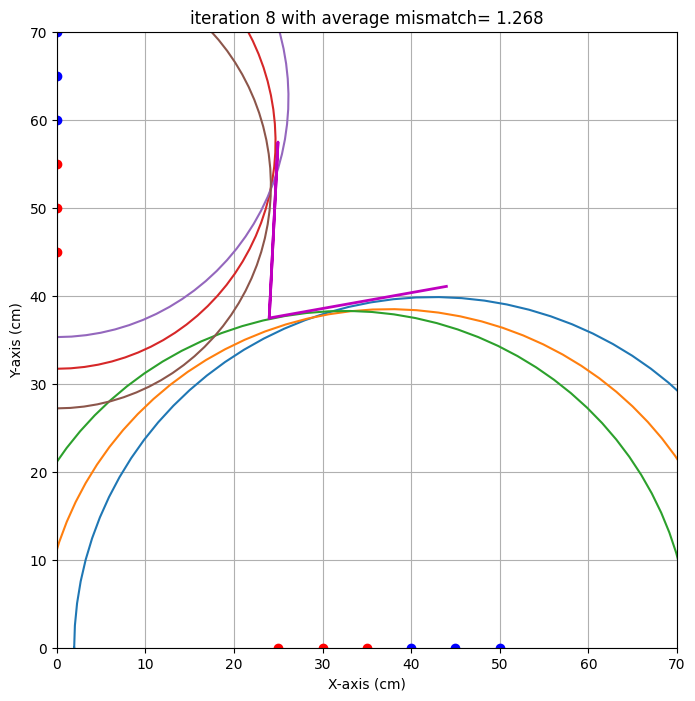

end iteration 8 with average mismatch= 1.268


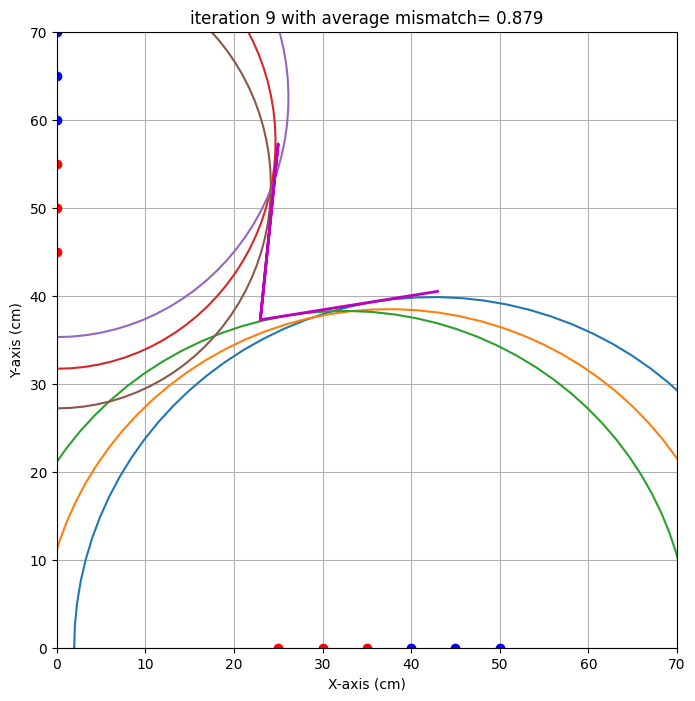

end iteration 9 with average mismatch= 0.879
end iteration 10 with average mismatch= 0.855
end iteration 11 with average mismatch= 0.850
end iteration 12 with average mismatch= 0.848
end iteration 13 with average mismatch= 0.848
end iteration 14 with average mismatch= 0.848
end iteration 15 with average mismatch= 0.848
end iteration 16 with average mismatch= 0.848


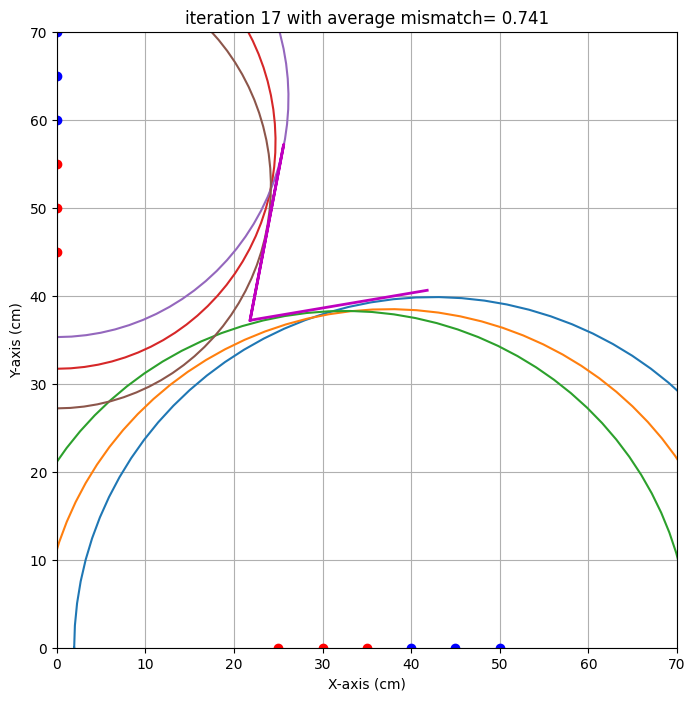

end iteration 17 with average mismatch= 0.741
end iteration 18 with average mismatch= 0.738
end iteration 19 with average mismatch= 0.737
end iteration 20 with average mismatch= 0.718
end iteration 21 with average mismatch= 0.702
end iteration 22 with average mismatch= 0.701
end iteration 23 with average mismatch= 0.701
end iteration 24 with average mismatch= 0.639
end iteration 25 with average mismatch= 0.622
end iteration 26 with average mismatch= 0.612
end iteration 27 with average mismatch= 0.607
end iteration 28 with average mismatch= 0.607
end iteration 29 with average mismatch= 0.607
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.607
###############################################################################
end of iteration  30
Best alpha=   8.91 with uncertainty=   3.39
Best beta =  12.04 with uncertainty=   2.80
Best x0   =  21.45 with uncertainty=   1.03
Best y0   =  3

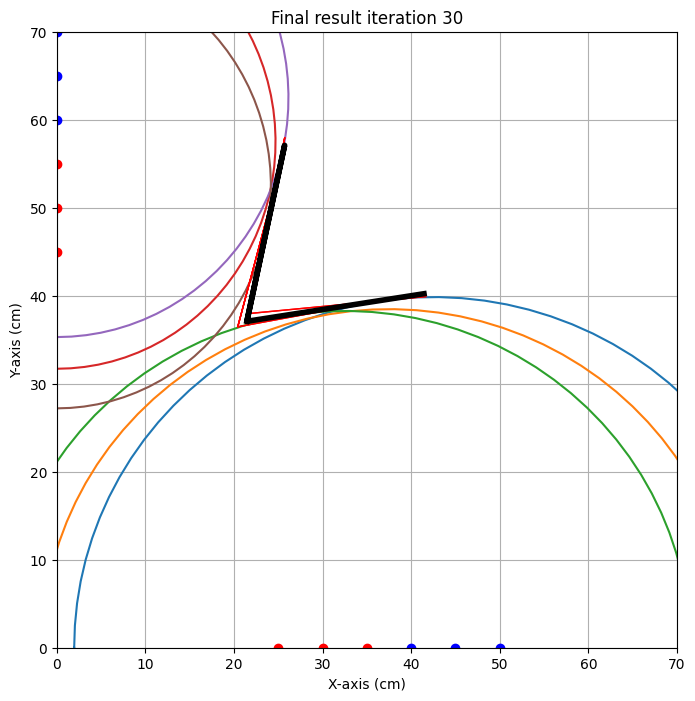

{'alpha': np.float64(8.905898210827342), 'alpha_eps': np.float64(3.390520806895853), 'beta': np.float64(12.03529969901501), 'beta_eps': np.float64(2.7950260717570057), 'x0': np.float64(21.44717130204054), 'x0_eps': np.float64(1.02936826267403), 'y0': np.float64(37.09483495660688), 'y0_eps': np.float64(0.8771513335079462)}
locatie 1 
x0 target is : 26.5. Gevonden waarde: 25.5 cm met een standaardafwijking van 2.1 cm 
y0 target is : 34.5. Gevonden waarde: 34.6 cm met een standaardafwijking van 1.9 cm 
alpha target is : 13.0. Gevonden waarde: 10.5 graden met een standaardafwijking van 6.9 graad 
beta target is : 13.0. Gevonden waarde: 15.0 graden met een standaardafwijking van 14.2 graad 

locatie 2 
x0 target is : 29.8. Gevonden waarde: 31.1 cm met een standaardafwijking van 1.7 cm 
y0 target is : 39.0. Gevonden waarde: 39.7 cm met een standaardafwijking van 1.2 cm 
alpha target is : 32.0. Gevonden waarde: 19.7 graden met een standaardafwijking van 5.5 graad 
beta target is : 15.0. Gevon

In [9]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 26.5, 
                    'y0': 34.5, 
                    'alpha' : 13,
                    'beta' : 13,},
            'locatie 2':{'x0': 29.8,
                    'y0': 39 ,
                    'alpha' : 32,
                    'beta' : 15,},
            'locatie 3':{'x0': 29.8,
                    'y0': 39 ,
                    'alpha' : 32,
                    'beta' : 15,},
            'locatie 4':{'x0': 20.5,
                    'y0': 42,
                    'alpha' : -13,
                    'beta' : 17,
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,30,0,ongeldig],
    [40,0,50,0,75.2],
    [45,0,55,0,77.6],
    [50,0,60,0,79.4],
    [35,0,45,0,72.6],
    [30,0,40,0,72],
    #[0,20,0,30,ongeldig],
    [0,40,0,50,54],
    [0,45,0,55,56.5],
    [0,50,0,60,60.6],
    [0,35,0,45,55.6],
    #[0,30,0,40,ongeldig],
    [0,55,0,65,67.8],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   # [35,0,50,0,ongeldig],
    [50,0,65,0,93.5],
    [52.5,0,67.5,0,95.1],
    [55,0,70,0,97],
    [47.5,0,62.5,0,91],
    [45,0,60,0,90.3],
    #[0,35,0,50,ongeldig],
    [0,50,0,65,67.8],
    [0,52.5,0,67.5,68.1],
    [0,55,0,70,70.7],
    [0,47.5,0,62.5,68],
    [0,45,0,60,67.1],
    ]),
           'locatie 3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   # [35,0,50,0,ongeldig],
    [50,0,65,0,92.4],
    [55,0,70,0,98],
    [45,0,60,0,89.6],
    #[0,35,0,50,ongeldig],
    [0,50,0,65,67.3],
    [0,55,0,70,69.6],
    [0,45,0,60,65.5],
    ]),
               'locatie 4' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35,0,50,0,81.1],
    [30,0,45,0,78.4],
    #[40,0,55,0,ongeldig],
    [25,0,40,0,78],
    #[0,35,0,50,ongeldig],
    [0,50,0,65,51.6],
    [0,55,0,70,54.4],
    [0,45,0,60,50.6],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  50   0  68.3
1  40   0  55   0  70.0
2  45   0  60   0  71.9
3   0  35   0  50  55.9
4   0  40   0  55  54.1
5   0  30   0  45  58.4


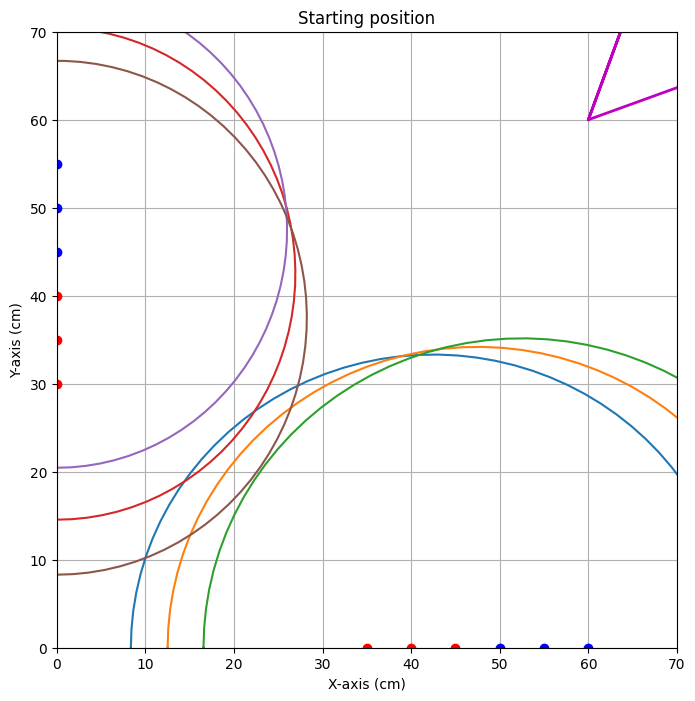


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.392
end iteration 2 with average mismatch=62.529


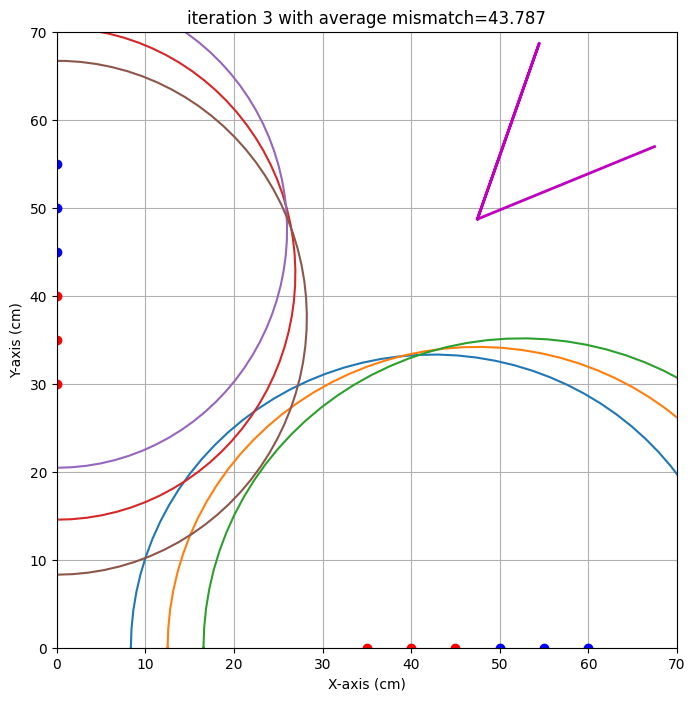

end iteration 3 with average mismatch=43.787


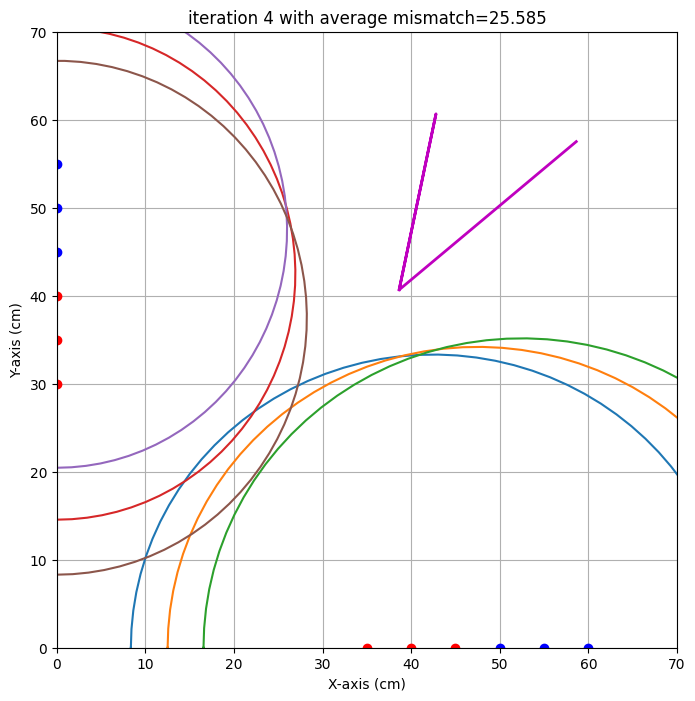

end iteration 4 with average mismatch=25.585


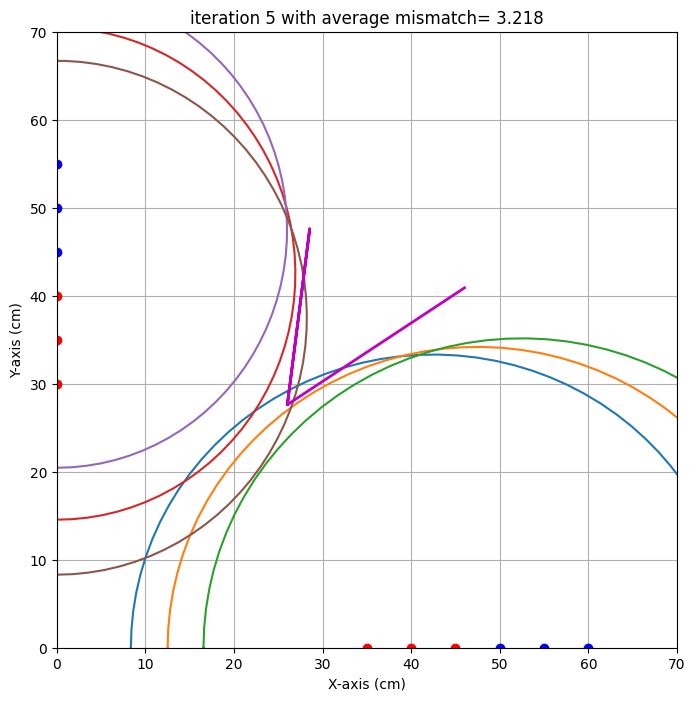

end iteration 5 with average mismatch= 3.218


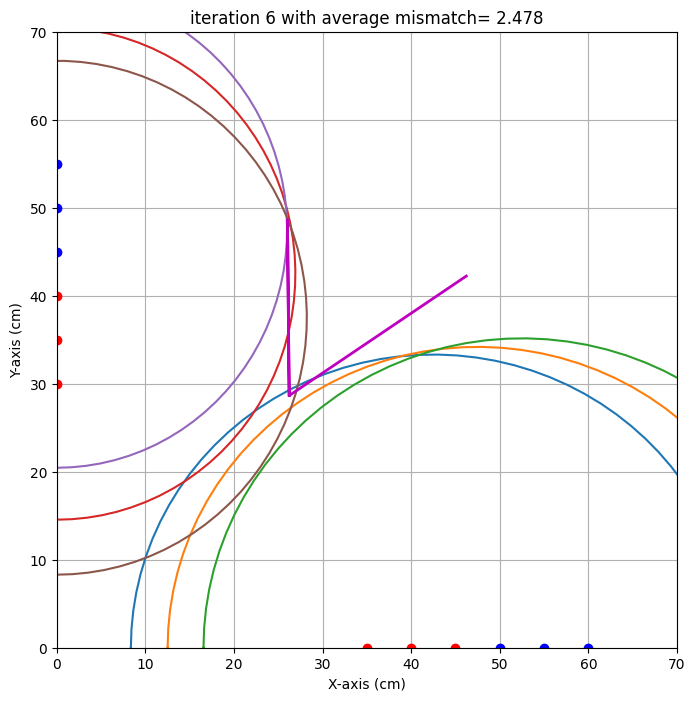

end iteration 6 with average mismatch= 2.478
end iteration 7 with average mismatch= 2.391


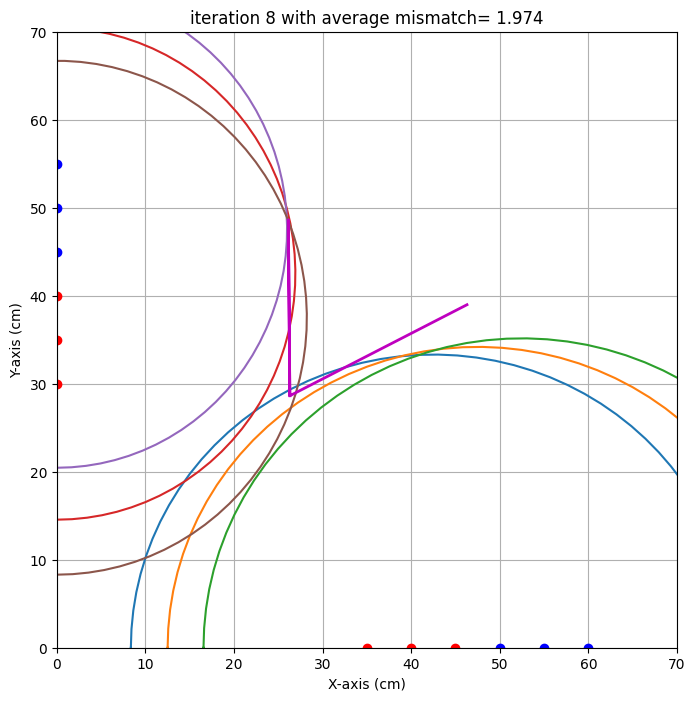

end iteration 8 with average mismatch= 1.974


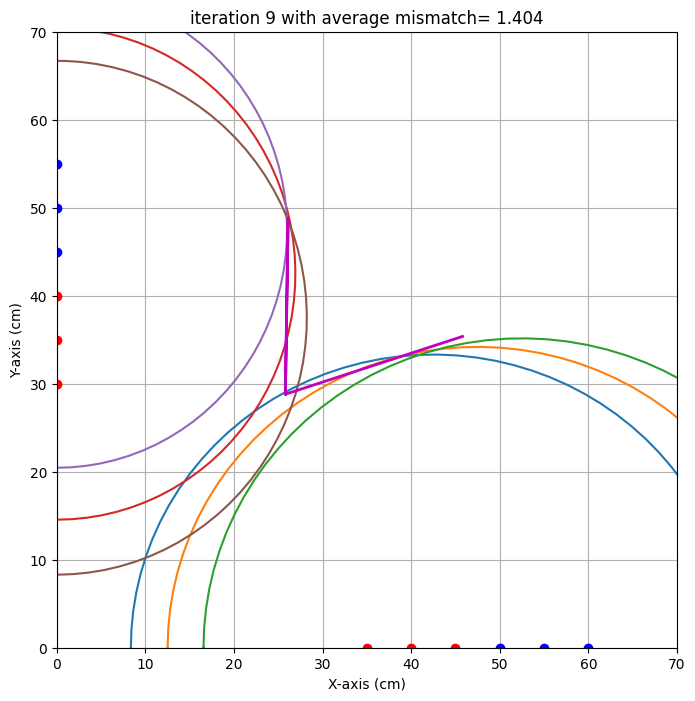

end iteration 9 with average mismatch= 1.404
end iteration 10 with average mismatch= 1.364
end iteration 11 with average mismatch= 1.361
end iteration 12 with average mismatch= 1.347
end iteration 13 with average mismatch= 1.267
end iteration 14 with average mismatch= 1.259
end iteration 15 with average mismatch= 1.216
end iteration 16 with average mismatch= 1.110
end iteration 17 with average mismatch= 1.109
end iteration 18 with average mismatch= 1.105
end iteration 19 with average mismatch= 1.103
end iteration 20 with average mismatch= 1.029
end iteration 21 with average mismatch= 1.025
end iteration 22 with average mismatch= 1.015
end iteration 23 with average mismatch= 1.002
end iteration 24 with average mismatch= 1.002
end iteration 25 with average mismatch= 1.002
end iteration 26 with average mismatch= 1.002
end iteration 27 with average mismatch= 1.002
end iteration 28 with average mismatch= 1.002
end iteration 29 with average mismatch= 1.002
Last iteration, also determine unce

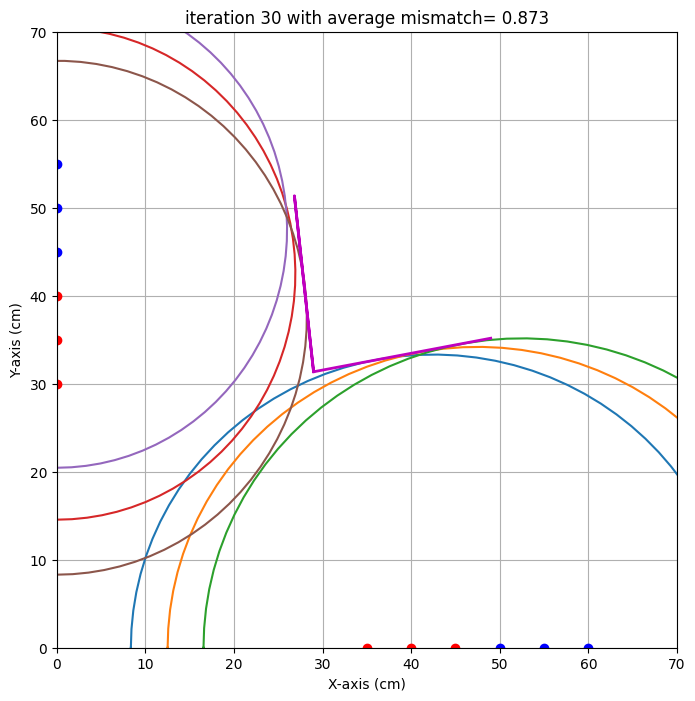

end iteration 30 with average mismatch= 0.873
###############################################################################
end of iteration  30
Best alpha=  10.79 with uncertainty=  10.32
Best beta =  -6.18 with uncertainty=  14.17
Best x0   =  28.98 with uncertainty=   3.26
Best y0   =  31.36 with uncertainty=   2.70
###############################################################################


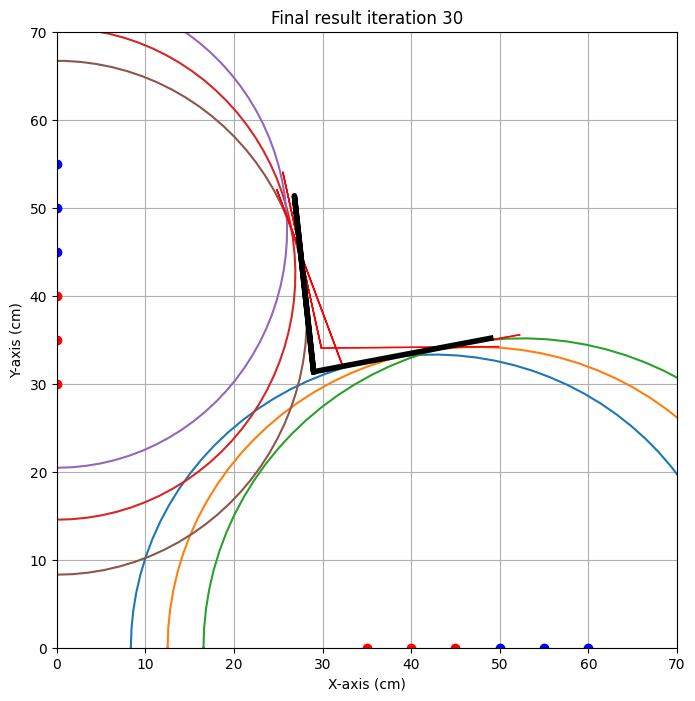

{'alpha': np.float64(10.789778445473527), 'alpha_eps': np.float64(10.322323784731461), 'beta': np.float64(-6.180103268241332), 'beta_eps': np.float64(14.17254096364239), 'x0': np.float64(28.978621220832807), 'x0_eps': np.float64(3.2646267548375434), 'y0': np.float64(31.35799435555778), 'y0_eps': np.float64(2.6958528293597226)}
test locatie 
x0 target is : 31.2. Gevonden waarde: 29.0 cm met een standaardafwijking van 3.3 cm 
y0 target is : 32.5. Gevonden waarde: 31.4 cm met een standaardafwijking van 2.7 cm 
alpha target is : 7.0. Gevonden waarde: 10.8 graden met een standaardafwijking van 10.3 graad 
beta target is : -18.0. Gevonden waarde: -6.2 graden met een standaardafwijking van 14.2 graad 



In [10]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  31.2, 
                    'y0':  32.5, 
                    'alpha' :  7, 
                    'beta' :  -18,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [35,0,50,0,68.3],
                    [40,0,55,0,70],
                    #[30,0,45,0,ongeldig],
                    [45,0,60,0,71.9],
                    [0,35,0,50,55.9],
                    [0,40,0,55,54.1],
                    [0,30,0,45,58.4],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
#### algoritme [Lars Mulder]
<img src="Algoritme_Lars.jpeg" width="400">

#### algoritme [Elisabeth Mijnders]
<img src="Algoritme_Elisabeth.jpeg" width="400">

#### algoritme [Oscar Pouw]
<img src="Algoritme_Oscar.jpg" width="400">


samenvoeging van alle 0e iteraties bij elkaar. als er een meting gedaan is een aantal extra metingen (met 5 cm afstand) in een kleine omgeving doen.
## Figuur: iteratie 1 ![Image](Iteratie1.jpeg) 

bij deze iteratie hebben we de afstand vergroot tussen de bron en ontvanger om het bereik te vergroten. ook is de afstand tussen de metingen verkleind (van 5 cm naar 2.5cm) om zo de onzekerheid te verkleinen 
## Figuur: iteratie 2 ![Image](Iteratie2.jpeg)

Bij deze iteratie zijn er maar 2 metingen om een gemeten punt gemeten in plaats van 4 en is de afstand tussen deze punten weer groter dan bij iteratie 2 (weer van 2.5 naar 5 cm). Dit is gedaan om de onzekerheid te verkleinen, want meer punten leverde een grotere onzekerheid op.
## Figuur: iteratie 3 ![Image](iteratie3.jpeg)

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  50   0  68.3
1  40   0  55   0  70.0
2  45   0  60   0  71.9
3   0  35   0  50  55.9
4   0  40   0  55  54.1
5   0  30   0  45  58.4


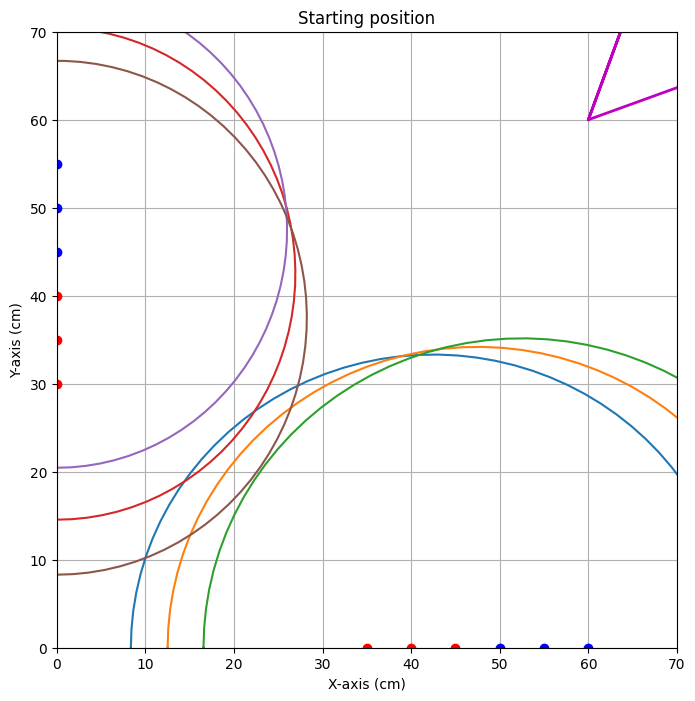


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.392


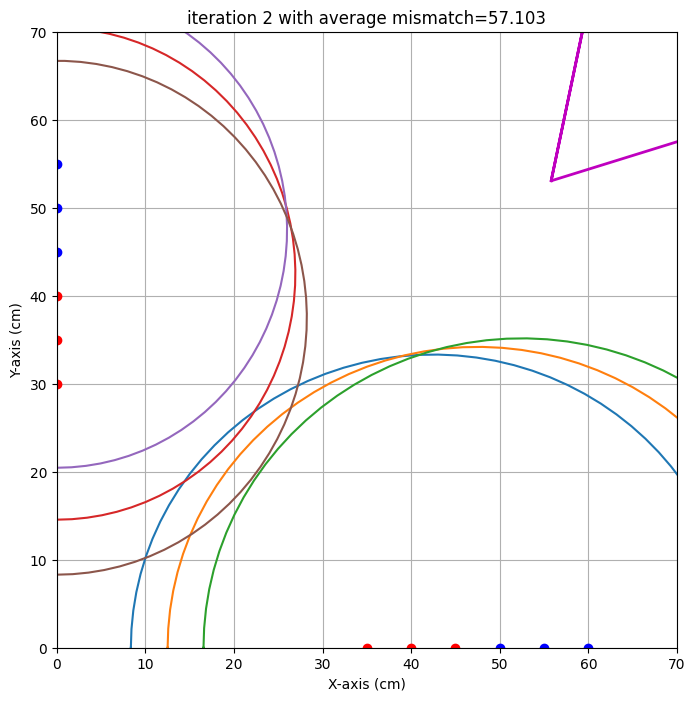

end iteration 2 with average mismatch=57.103


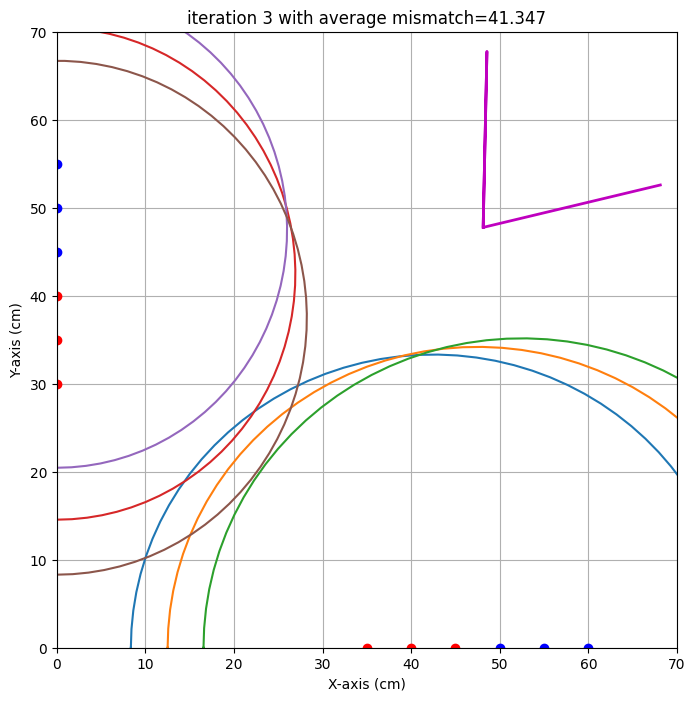

end iteration 3 with average mismatch=41.347


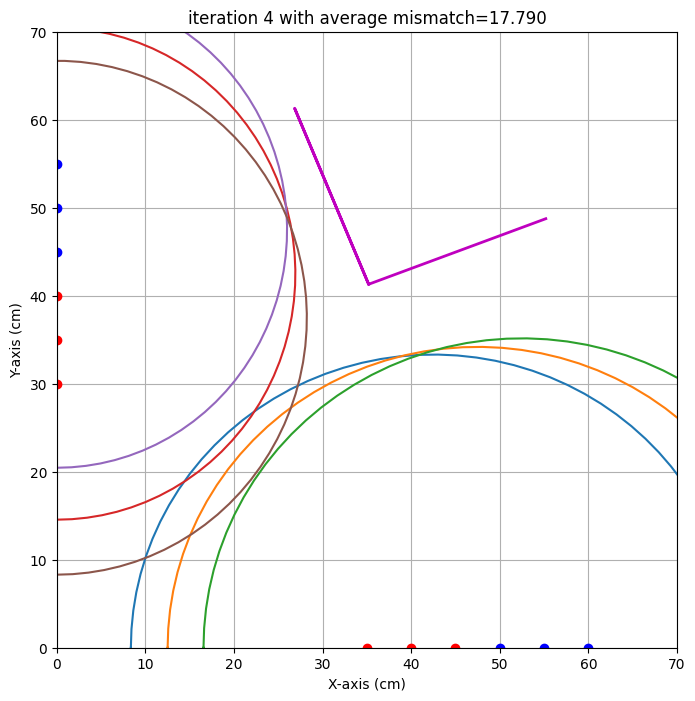

end iteration 4 with average mismatch=17.790


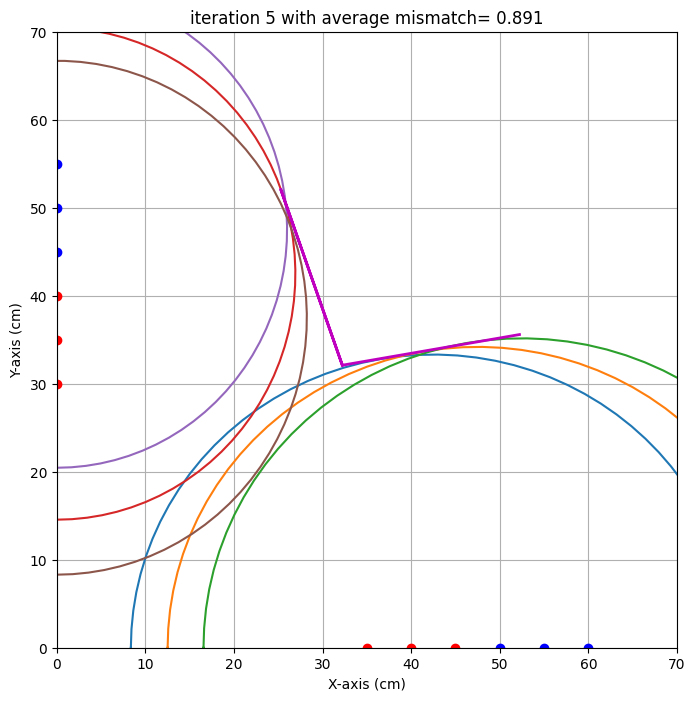

end iteration 5 with average mismatch= 0.891


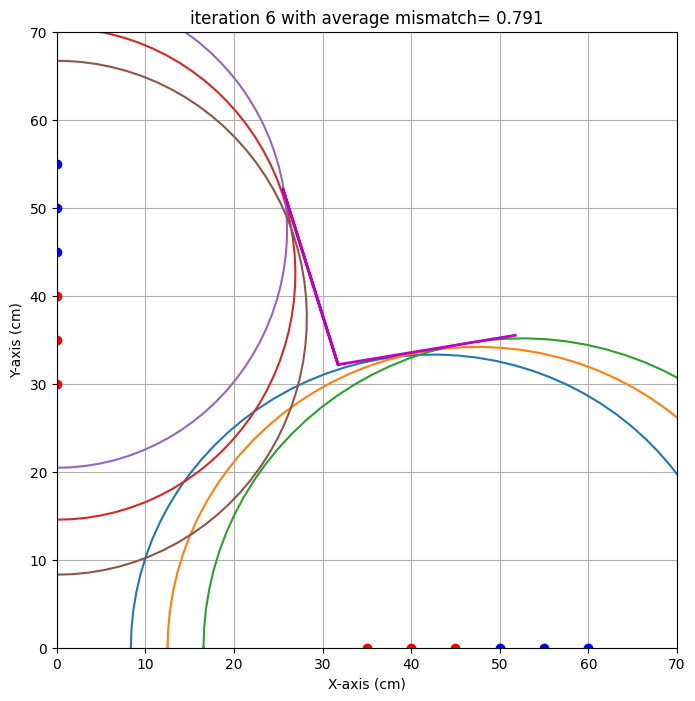

end iteration 6 with average mismatch= 0.791


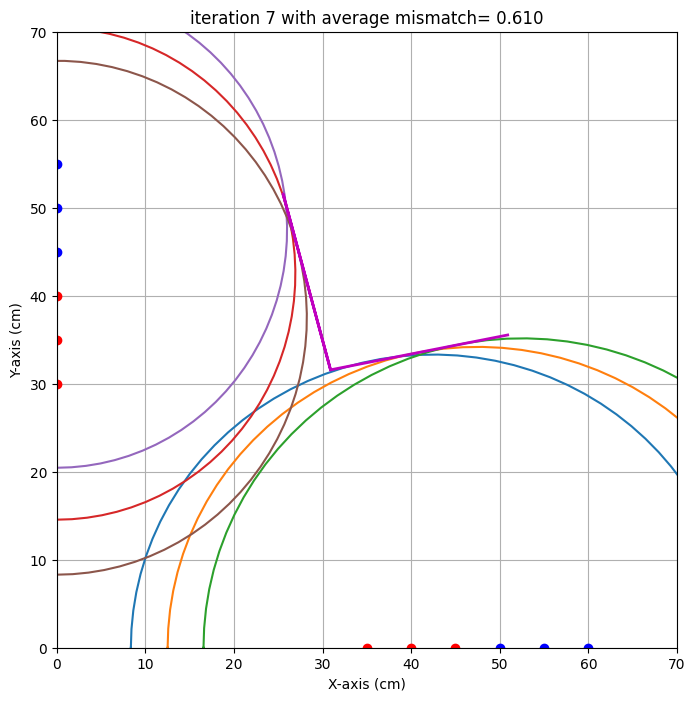

end iteration 7 with average mismatch= 0.610
end iteration 8 with average mismatch= 0.605
end iteration 9 with average mismatch= 0.604
end iteration 10 with average mismatch= 0.604
end iteration 11 with average mismatch= 0.604
end iteration 12 with average mismatch= 0.604
end iteration 13 with average mismatch= 0.604
end iteration 14 with average mismatch= 0.604


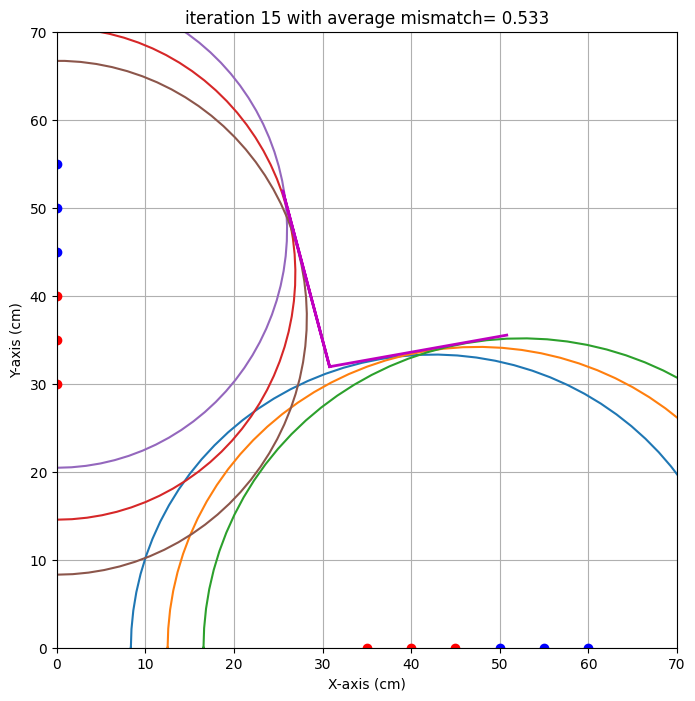

end iteration 15 with average mismatch= 0.533
end iteration 16 with average mismatch= 0.526
end iteration 17 with average mismatch= 0.498
end iteration 18 with average mismatch= 0.485
end iteration 19 with average mismatch= 0.484
end iteration 20 with average mismatch= 0.483
end iteration 21 with average mismatch= 0.483
end iteration 22 with average mismatch= 0.483
end iteration 23 with average mismatch= 0.483
end iteration 24 with average mismatch= 0.483
end iteration 25 with average mismatch= 0.483
end iteration 26 with average mismatch= 0.483
end iteration 27 with average mismatch= 0.483
end iteration 28 with average mismatch= 0.483
end iteration 29 with average mismatch= 0.483
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.483
###############################################################################
end of iteration  30
Best alpha=  10.16 with uncertainty=   3.47
Best beta 

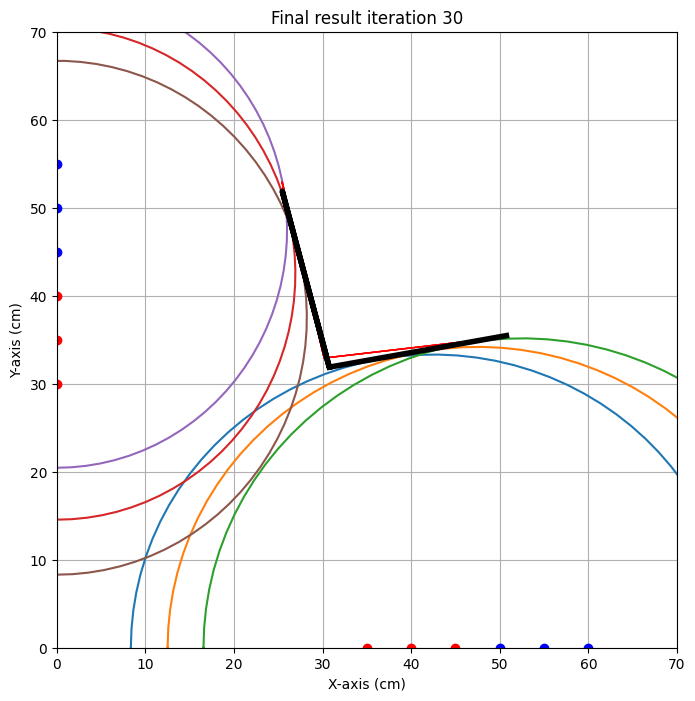

{'alpha': np.float64(10.161313009532153), 'alpha_eps': np.float64(3.4718147252455527), 'beta': np.float64(-14.865865144403703), 'beta_eps': np.float64(1.4893909873617286), 'x0': np.float64(30.751491716732914), 'x0_eps': np.float64(0.5748384925323506), 'y0': np.float64(31.88264791077401), 'y0_eps': np.float64(1.035832077524823)}
test locatie 
x0 target is : 31.2. Gevonden waarde: 30.8 cm met een standaardafwijking van 0.6 cm 
y0 target is : 32.5. Gevonden waarde: 31.9 cm met een standaardafwijking van 1.0 cm 
alpha target is : 7.0. Gevonden waarde: 10.2 graden met een standaardafwijking van 3.5 graad 
beta target is : -18.0. Gevonden waarde: -14.9 graden met een standaardafwijking van 1.5 graad 



In [11]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  31.2, 
                    'y0':  32.5, 
                    'alpha' :  7, 
                    'beta' :  -18,
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [35,0,50,0,68.3],
                    [40,0,55,0,70],
                    #[30,0,45,0,ongeldig],
                    [45,0,60,0,71.9],
                    [0,35,0,50,55.9],
                    [0,40,0,55,54.1],
                    [0,30,0,45,58.4],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))